# renquant_103 — Adaptive Regime Multi-Stock Strategy

**New vs 102**: 3-layer regime detection (Hurst + CUSUM + GMM), regime-conditional entry, relative-strength ranking, correlation-aware selection, earnings filter, defensive tickers (GLD/TLT/XLV/XLU).

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ROOT detection: handles Notebooks/, backtesting/renquant_103/, or repo root
_cwd = Path.cwd()
if _cwd.name == "Notebooks":
    ROOT = _cwd.parent
elif (_cwd / "strategy_config.json").exists():
    # Running from backtesting/<strategy>/ directory (e.g. nbconvert, LEAN docker)
    ROOT = _cwd.parent.parent
else:
    ROOT = _cwd  # repo root

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

STRATEGY   = "renquant_103"
STRATEGY_DIR = ROOT / "backtesting" / STRATEGY

# Add strategy dir to path so kernel.* and training.* imports work throughout the notebook
if str(STRATEGY_DIR) not in sys.path:
    sys.path.insert(0, str(STRATEGY_DIR))

from kernel.data import fetch_ohlcv
from kernel.regime import compute_hurst, rolling_hurst, compute_cusum, rolling_cusum
from training.regime import build_gmm_features, RegimeGMM
from training.models import create_model
from training.scoring import fit_probability_calibration, raw_score_kind_for_model
from kernel.config import load_strategy_config
from training.portfolio import portfolio_stats
from training.pipeline import TrainingContext, TrainingPipeline
from training.pipeline import (
    DataFetchJob, RegimeFitJob, FeatureJob, TournamentJob,
    ExportJob, CorrelationJob, CalibrationJob,
)

CONFIG     = load_strategy_config(STRATEGY_DIR / "strategy_config.json")
WATCHLIST  = CONFIG["watchlist"]
DEFENSIVE  = set(CONFIG.get("defensive_tickers", []))
SECTOR_ETF = CONFIG.get("sector_etf_map", {})

# Inject runtime-only config fields consumed by pipeline jobs
CONFIG["_strategy_dir"]  = str(STRATEGY_DIR)
CONFIG["_strategy_name"] = STRATEGY

# Shared context — all pipeline jobs read/write this object
train_ctx = TrainingContext(config=CONFIG)

print(f"Strategy : {STRATEGY}")
print(f"ROOT     : {ROOT}")
print(f"Watchlist: {WATCHLIST}")
print(f"Defensive: {sorted(DEFENSIVE)}")

Strategy : renquant_103
ROOT     : /Users/renhao/git/github/RenQuant
Watchlist: ['TSLA', 'AMZN', 'GOOG', 'MSFT', 'AMD', 'NFLX', 'CRM', 'PLTR', 'UBER', 'NVDA', 'META', 'AAPL', 'JPM', 'UNH', 'CAT', 'BA', 'XLE', 'XLF', 'LLY', 'GLD', 'TLT', 'XLV', 'XLU']
Defensive: ['GLD', 'TLT', 'XLU', 'XLV']


## 1  Fetch OHLCV data

In [2]:
SAMPLE_START = CONFIG["sample_start"]
SAMPLE_END   = CONFIG["sample_end"]

# Fetch OHLCV for watchlist + sector ETFs + SPY
DataFetchJob().run(train_ctx)

# Convenience aliases used by visualisation cells below
ohlcv  = train_ctx.ohlcv
spy_df = train_ctx.spy_df

print(f"Fetched {len(ohlcv)} symbols: {sorted(ohlcv.keys())}")
print(f"Date range: {spy_df.index[0].date()} → {spy_df.index[-1].date()} ({len(spy_df)} bars)")

DataFetchJob: fetching 26 tickers 2016-01-01 → 2026-06-30


  AAPL: 2588 rows


  AMD: 2588 rows


  AMZN: 2588 rows


  BA: 2588 rows


...

  XLF: 2588 rows


  XLI: 2588 rows


  XLK: 2588 rows


  XLU: 2588 rows


  XLV: 2588 rows
DataFetchJob: loaded 26 / 26 tickers
Fetched 26 symbols: ['AAPL', 'AMD', 'AMZN', 'BA', 'CAT', 'CRM', 'GLD', 'GOOG', 'JPM', 'LLY', 'META', 'MSFT', 'NFLX', 'NVDA', 'PLTR', 'SPY', 'TLT', 'TSLA', 'UBER', 'UNH', 'XLE', 'XLF', 'XLI', 'XLK', 'XLU', 'XLV']
Date range: 2016-01-04 → 2026-04-20 (2588 bars)


## 2  SPY Regime Analysis — 3-Layer Detection

In [3]:
# ── Regime detection: Hurst + CUSUM + GMM → final daily regime ───────────────
# RegimeFitJob runs all three layers and saves the GMM artifact.
RegimeFitJob().run(train_ctx)

# Unpack for visualisation cells
BULL_CALM, BULL_VOLATILE, CHOPPY, BEAR = "BULL_CALM", "BULL_VOLATILE", "CHOPPY", "BEAR"
hurst_series       = train_ctx.hurst_series
cusum_series       = train_ctx.cusum_series
changepoint_dates  = train_ctx.changepoint_dates
final_regime       = train_ctx.final_regime
final_regime_conf  = train_ctx.final_regime_conf
gmm                = train_ctx.gmm
regime_labels, regime_probs = gmm.predict(
    build_gmm_features(spy_df, vol_window=20, hurst_window=CONFIG["regime"]["hurst_window"])
)
spy_returns = spy_df["close"].pct_change().dropna()

HurstCUSUMTask: CUSUM detected 420 changepoints
HurstCUSUMTask: Hurst 0.472–0.875 (mean=0.702)


RegimeCombineTask: Final regime distribution:
BULL_CALM        2151
BULL_VOLATILE     230
BEAR              129
CHOPPY             15
RegimeSaveTask: GMM artifact saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/spy-gmm-regime.json


In [4]:
# (GMM fit is now part of RegimeFitJob above — see train_ctx.gmm)
print(f"GMM cluster labels: {train_ctx.gmm.cluster_labels}")
print(f"GMM weights: {np.round(train_ctx.gmm._gmm.weights_, 3)}")
print("\nRegime distribution:")
print(train_ctx.final_regime.value_counts())

GMM cluster labels: ['BULL_CALM', 'BULL_VOLATILE', 'BEAR']
GMM weights: [0.478 0.481 0.041]

Regime distribution:
BULL_CALM        2151
BULL_VOLATILE     230
BEAR              129
CHOPPY             15
Name: count, dtype: int64


## 3  Regime Charts

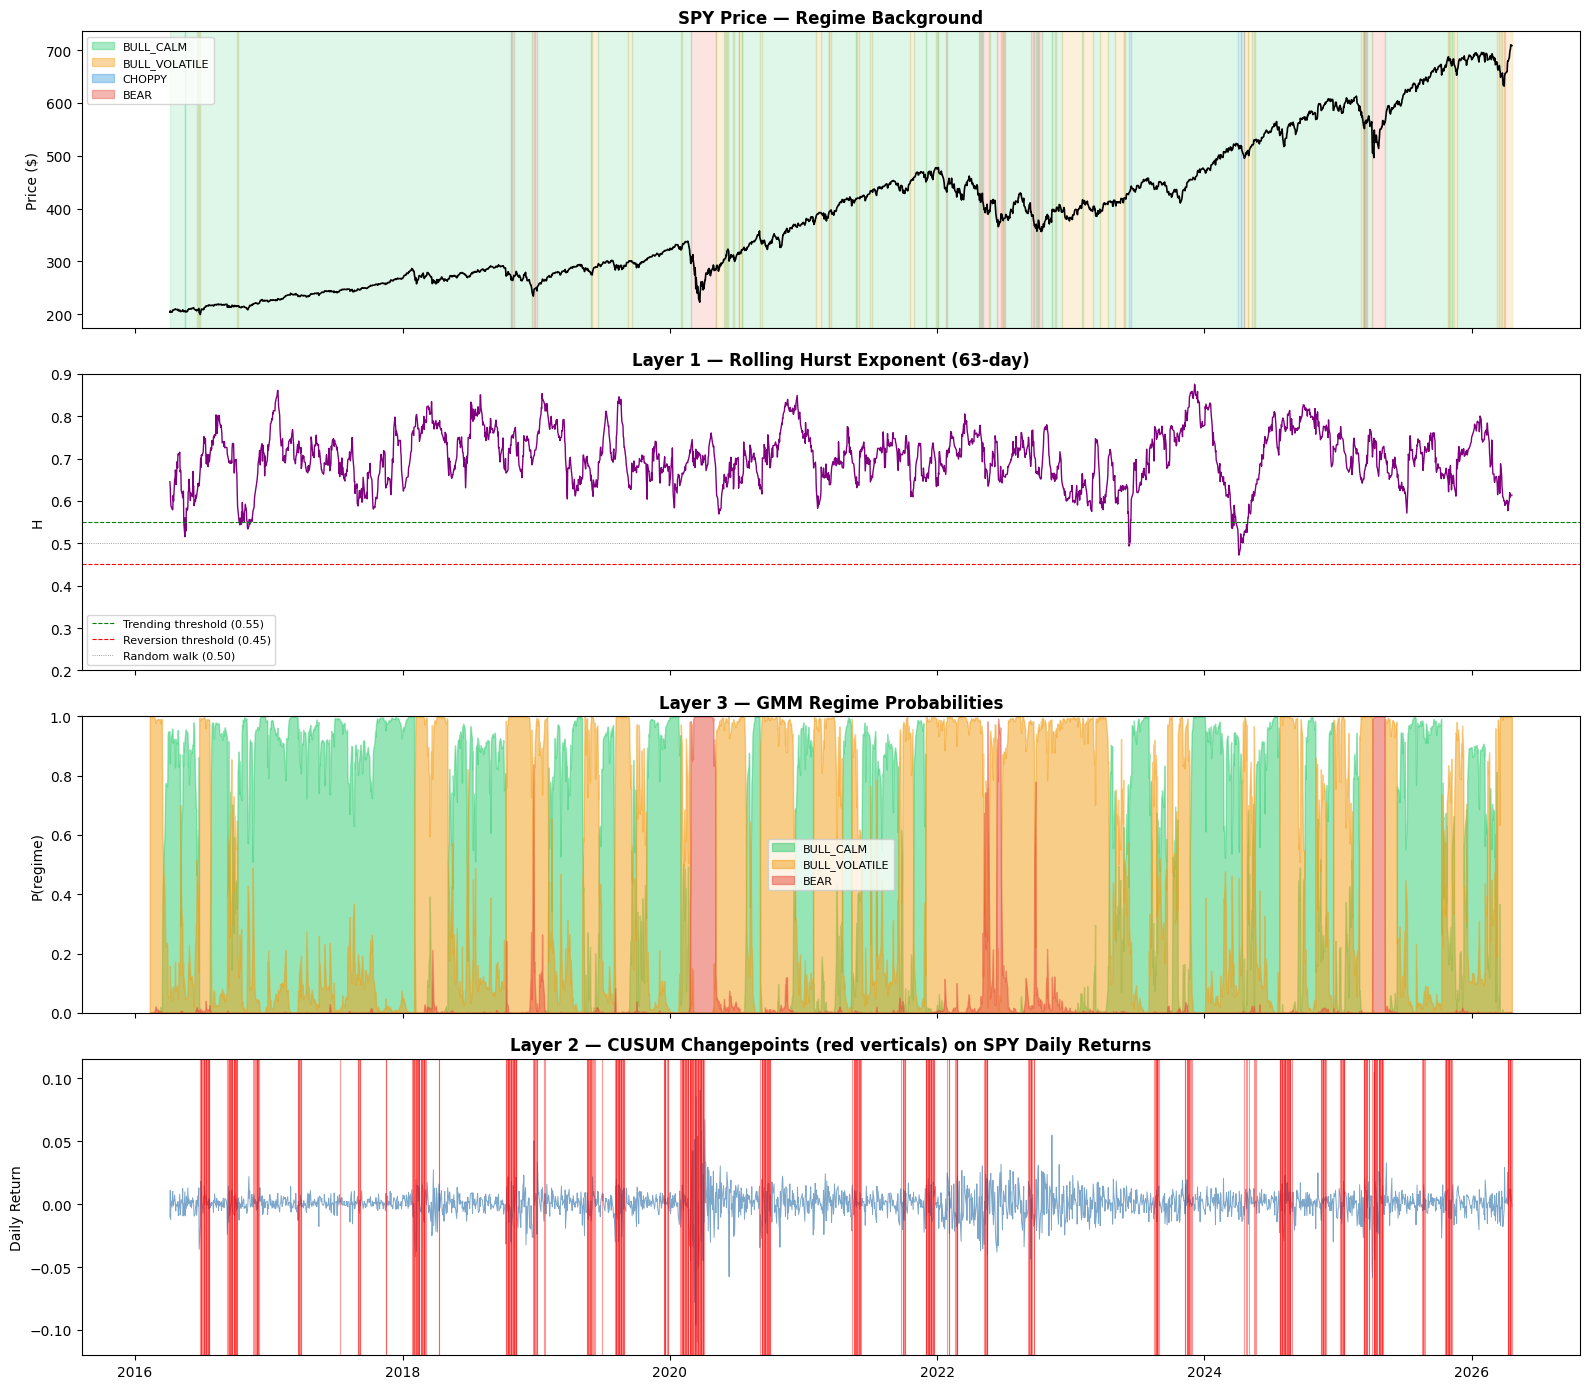

Chart saved → img/regime_analysis.png


In [5]:
REGIME_COLORS = {
    BULL_CALM:     "#2ecc71",   # green
    BULL_VOLATILE: "#f39c12",   # orange
    CHOPPY:        "#3498db",   # blue
    BEAR:          "#e74c3c",   # red
}

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

spy_close = spy_df["close"].reindex(final_regime.index)

# Panel 1: SPY price with regime background shading
ax = axes[0]
ax.plot(spy_close.index, spy_close.values, color="black", lw=1.2, label="SPY Close")
prev_regime = None
start_date  = None
for date in final_regime.index:
    r = final_regime.loc[date]
    if r != prev_regime:
        if prev_regime is not None:
            ax.axvspan(start_date, date, alpha=0.15,
                       color=REGIME_COLORS.get(prev_regime, "grey"))
        prev_regime = r
        start_date  = date
if prev_regime:
    ax.axvspan(start_date, final_regime.index[-1], alpha=0.15,
               color=REGIME_COLORS.get(prev_regime, "grey"))
patches = [mpatches.Patch(color=c, alpha=0.4, label=r)
           for r, c in REGIME_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title("SPY Price — Regime Background", fontweight="bold")
ax.set_ylabel("Price ($)")

# Panel 2: Hurst exponent
ax = axes[1]
ax.plot(hurst_series.index, hurst_series.values, color="purple", lw=1.0)
ax.axhline(0.55, color="green",  ls="--", lw=0.8, label="Trending threshold (0.55)")
ax.axhline(0.45, color="red",    ls="--", lw=0.8, label="Reversion threshold (0.45)")
ax.axhline(0.50, color="grey",   ls=":",  lw=0.6, label="Random walk (0.50)")
ax.set_ylim(0.2, 0.9)
ax.set_title("Layer 1 — Rolling Hurst Exponent (63-day)", fontweight="bold")
ax.set_ylabel("H")
ax.legend(fontsize=8)

# Panel 3: GMM regime probabilities
ax = axes[2]
for regime, color in REGIME_COLORS.items():
    if regime in regime_probs.columns:
        ax.fill_between(regime_probs.index, regime_probs[regime],
                        alpha=0.5, label=regime, color=color)
ax.set_ylim(0, 1)
ax.set_title("Layer 3 — GMM Regime Probabilities", fontweight="bold")
ax.set_ylabel("P(regime)")
ax.legend(fontsize=8)

# Panel 4: CUSUM changepoints on SPY returns
ax = axes[3]
ax.plot(spy_returns.reindex(final_regime.index).index,
        spy_returns.reindex(final_regime.index).values,
        color="steelblue", lw=0.7, alpha=0.7)
for d in changepoint_dates:
    if d in final_regime.index:
        ax.axvline(d, color="red", alpha=0.4, lw=0.8)
ax.set_title("Layer 2 — CUSUM Changepoints (red verticals) on SPY Daily Returns",
             fontweight="bold")
ax.set_ylabel("Daily Return")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → img/regime_analysis.png")


## 4  Training Pipeline — parallel per-ticker (Feature → Tournament → Export → Calibrate)

In [6]:
# Phase 2: parallel per-ticker training chain
# FeatureJob orchestrates: Feature → Tournament → Export → Calibrate for every ticker
# All tickers run concurrently in ThreadPoolExecutor
FeatureJob().run(train_ctx)

# Convenience aliases
INDICATOR_SPEC = CONFIG["indicator_spec"]
MODEL_PARAMS   = CONFIG["model_params"]
FEATURE_COLS   = MODEL_PARAMS["feature_columns"]
LOOKAHEAD      = MODEL_PARAMS["lookahead"]
THRESHOLD      = MODEL_PARAMS["threshold"]
feature_frames = train_ctx.feature_frames
results        = train_ctx.results
exported       = train_ctx.exported

# ── Model summary table ───────────────────────────────────────────────────────
import pandas as _pd

rows = []
for t in WATCHLIST:
    r = results.get(t, {})
    cal = train_ctx.calibration_summary.get(t, {})
    rows.append({
        "Ticker":        t,
        "Best Model":    r.get("best_approach", "—"),
        "OOS Sharpe":    f"{r.get('sharpe', 0):.3f}" if r else "—",
        "Passes Floor":  "✓" if r.get("passes_floor") else "✗",
        "Train Rows":    r.get("train_rows", "—"),
        "OOS Rows":      r.get("oos_rows", "—"),
        "Cal Method":    cal.get("method", "—"),
        "Cal N":         cal.get("n", "—"),
    })

summary_df = _pd.DataFrame(rows).set_index("Ticker")
print(f"\nExported {len(exported)}/{len(WATCHLIST)} models  ")
print(f"Calibrated {len(train_ctx.calibration_summary)} models  ")
display(summary_df)

FeatureJob: launching parallel chain for 23 tickers


  [PLTR]   PLTR Classification OOS Sharpe: 1.350
  [PLTR]   PLTR QLearning    OOS Sharpe: 1.829
  [PLTR]   PLTR Manual       OOS Sharpe: 0.461
  [PLTR]   PLTR XGBoost      OOS Sharpe: 2.109
  [PLTR]   PLTR XGBoost error: 'XGBoostModel' object has no attribute 'predict_score'
  [PLTR]   → WINNER: XGBoost  Sharpe=2.109  ✓ PASS


=== Live model refresh: expanding window up to 2026-04-20 ===


  PLTR: XGBoost, 998 rows, train_end=2026-04-13
Live model refresh complete.


  [NFLX]   NFLX Classification OOS Sharpe: 0.703
  [NFLX]   NFLX QLearning    OOS Sharpe: 1.351
  [NFLX]   NFLX Manual       OOS Sharpe: 0.229
  [NFLX]   NFLX XGBoost      OOS Sharpe: 0.712
  [NFLX]   → WINNER: QLearning  Sharpe=1.351  ✓ PASS



  [TSLA]   TSLA Classification OOS Sharpe: 0.277
  [TSLA]   TSLA QLearning    OOS Sharpe: 0.651
  [TSLA]   TSLA Manual       OOS Sharpe: 0.342
  [TSLA]   TSLA XGBoost      OOS Sharpe: 1.039
  [TSLA]   TSLA XGBoost error: 'XGBoostModel' object has no attribute 'predict_score'
  [TSLA]   → WINNER: XGBoost  Sharpe=1.039  ✓ PASS


=== Live model refresh: expanding window up to 2026-04-20 ===
  [GOOG]   GOOG Classification OOS Sharpe: 0.058
  [GOOG]   GOOG QLearning    OOS Sharpe: 0.957
  [GOOG]   GOOG Manual       OOS Sharpe: 0.489
  [GOOG]   GOOG XGBoost      OOS Sharpe: 0.955
  [GOOG]   → WINNER: QLearning  Sharpe=0.957  ✗ FAIL (no model exported)

  [AMD]   AMD Classification OOS Sharpe: 1.178
  [AMD]   AMD QLearning    OOS Sharpe: 0.566
  [AMD]   AMD Manual       OOS Sharpe: 0.895
  [AMD]   AMD XGBoost      OOS Sharpe: 0.314
  [AMD]   → WINNER: Classification  Sharpe=1.178  ✓ PASS



...


=== Live model refresh: expanding window up to 2026-04-20 ===


  [TLT]   TLT Classification OOS Sharpe: 0.536
  [TLT]   TLT QLearning    OOS Sharpe: -0.585
  [TLT]   TLT Manual       OOS Sharpe: -0.454
  [TLT]   TLT XGBoost      OOS Sharpe: -0.037
  [TLT]   → WINNER: Classification  Sharpe=0.536  ✗ FAIL (no model exported)

  GLD: QLearning, 998 rows, train_end=2026-04-13
Live model refresh complete.


  [XLU]   XLU Classification OOS Sharpe: -0.185
  [XLU]   XLU QLearning    OOS Sharpe: 1.360
  [XLU]   XLU Manual       OOS Sharpe: 0.736
  [XLU]   XLU XGBoost      OOS Sharpe: 1.408
  [XLU]   XLU XGBoost error: 'XGBoostModel' object has no attribute 'predict_score'
  [XLU]   → WINNER: XGBoost  Sharpe=1.408  ✓ PASS


=== Live model refresh: expanding window up to 2026-04-20 ===


  LLY: XGBoost, 998 rows, train_end=2026-04-13
Live model refresh complete.
  XLU: XGBoost, 998 rows, train_end=2026-04-13
Live model refresh complete.
  parallel phase done in 70.7s  (23 tickers, 8 workers)
FeatureJob: 23 feature frames, 14/23 passed Sharpe floor, 14 exported, 0 calibrated

Exported 14/23 models  
Calibrated 0 models  


,Best Model,OOS Sharpe,Passes Floor,Train Rows,OOS Rows,Cal Method,Cal N
Ticker,,,,,,,
TSLA,XGBoost,1.039,✓,1926,571,—,—
AMZN,XGBoost,1.180,✓,1926,571,—,—
GOOG,QLearning,0.957,✗,1926,571,—,—
MSFT,Manual,0.320,✗,1926,571,—,—
AMD,Classification,1.178,✓,1926,571,—,—
NFLX,QLearning,1.351,✓,1926,571,—,—
CRM,Classification,-0.119,✗,1926,571,—,—
PLTR,XGBoost,2.109,✓,732,571,—,—
UBER,QLearning,0.922,✗,1083,571,—,—


## 5  Correlation Artifact

Sharpe floor  : 1.0
Results ready : 23 tickers
Exported      : 14  ['AAPL', 'AMD', 'AMZN', 'CAT', 'GLD', 'JPM', 'LLY', 'META', 'NFLX', 'NVDA', 'PLTR', 'TSLA', 'XLF', 'XLU']
Today         : 2026-04-20

CorrelationJob: saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/watchlist-correlation.json


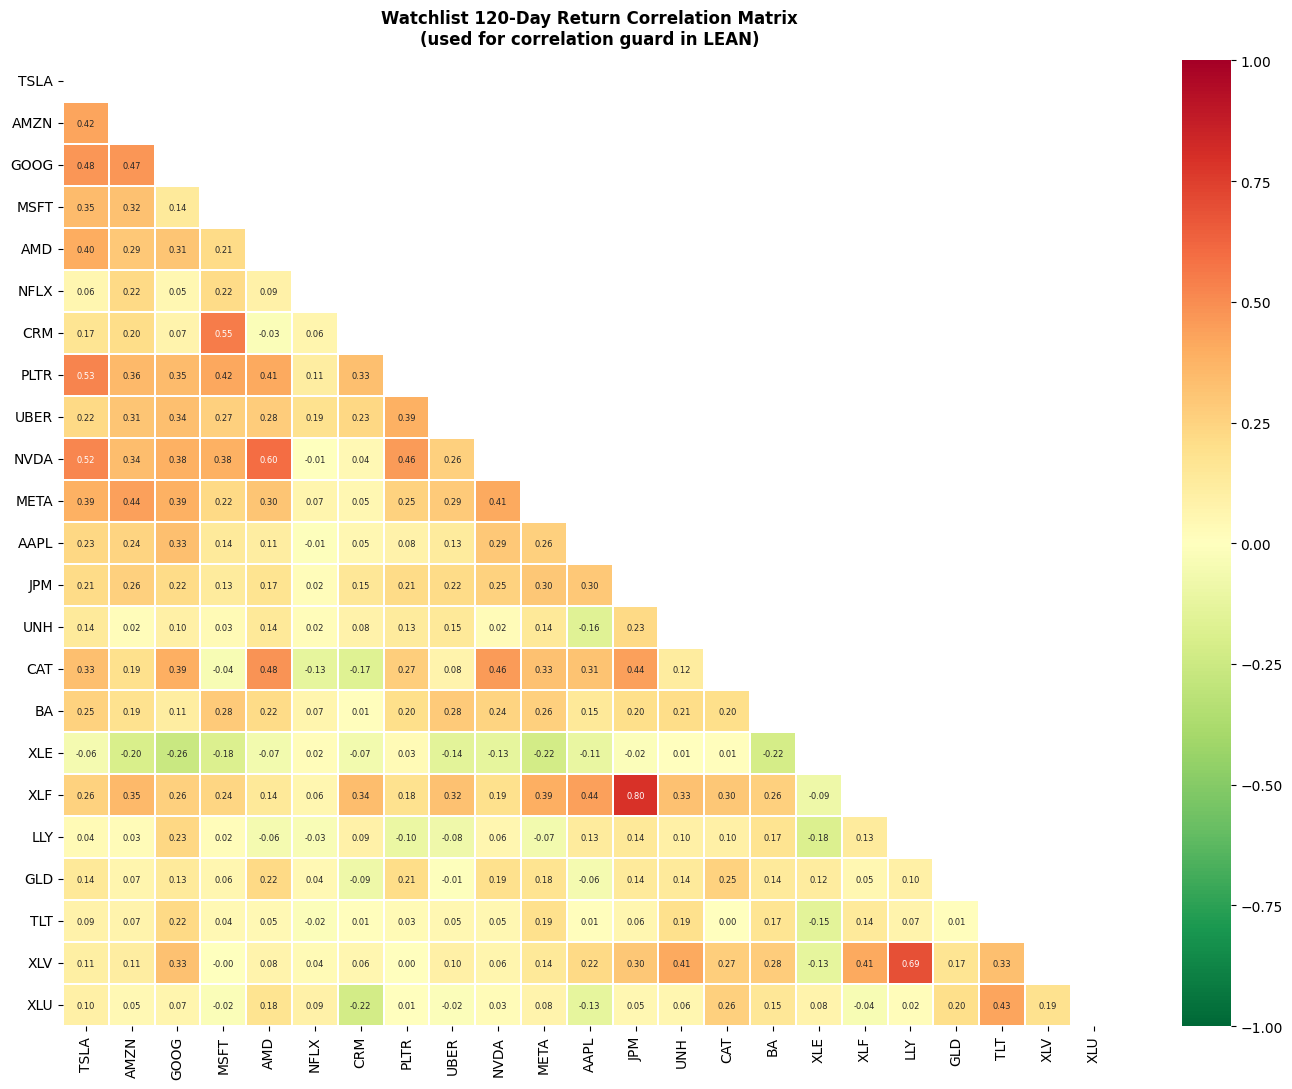

Heatmap saved → img/correlation_heatmap.png


In [7]:
import datetime
SHARPE_FLOOR = float(CONFIG.get("sharpe_floor", 0.8))
print(f"Sharpe floor  : {SHARPE_FLOOR}")
print(f"Results ready : {len(results)} tickers")
print(f"Exported      : {len(exported)}  {sorted(exported)}")
print(f"Today         : {datetime.date.today()}")
print()

# Compute and save the correlation artifact
CorrelationJob().run(train_ctx)

corr_matrix = train_ctx.corr_matrix

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={"size": 6})
ax.set_title("Watchlist 120-Day Return Correlation Matrix\n(used for correlation guard in LEAN)",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → img/correlation_heatmap.png")

## 6  Model Sharpe Chart

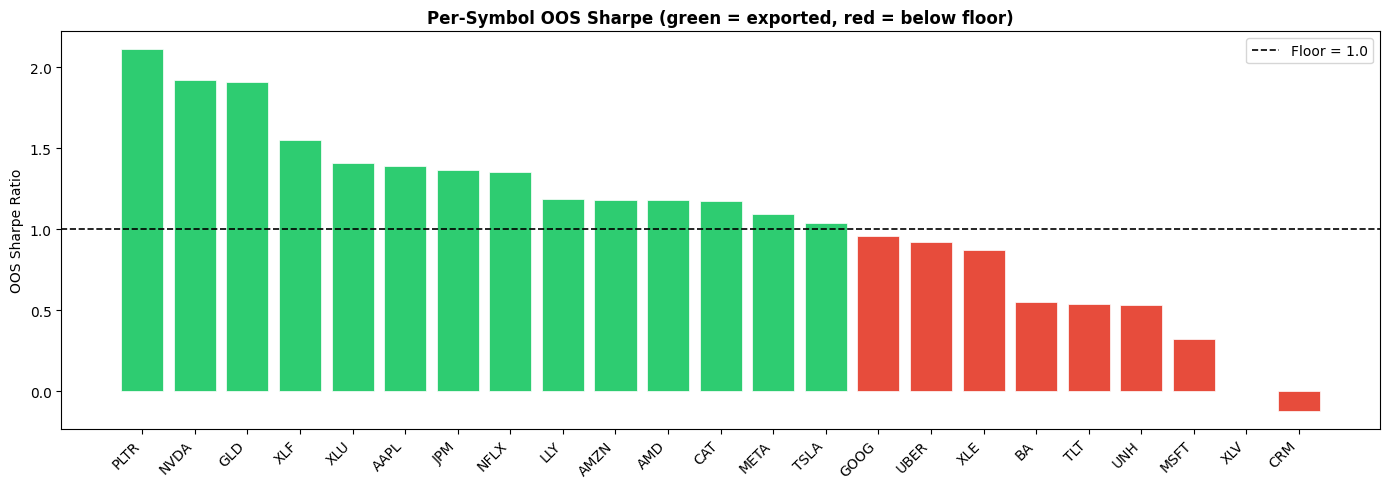

In [8]:
# Bar chart of OOS Sharpes
sharpe_vals = {k: v.get("sharpe", 0) for k, v in results.items()}
sharpe_s = pd.Series(sharpe_vals).sort_values(ascending=False)
colors = ["#2ecc71" if v >= SHARPE_FLOOR else "#e74c3c" for v in sharpe_s.values]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(sharpe_s.index, sharpe_s.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(SHARPE_FLOOR, color="black", ls="--", lw=1.2, label=f"Floor = {SHARPE_FLOOR}")
ax.set_title("Per-Symbol OOS Sharpe (green = exported, red = below floor)", fontweight="bold")
ax.set_ylabel("OOS Sharpe Ratio")
ax.set_xticklabels(sharpe_s.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "model_sharpe_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 9  Portfolio Simulation (mirrors LEAN regime-aware logic)

In [9]:
# ────────────────────────────────────────────────────────────────────────────
# Portfolio Simulation — kernel-based, streaming regime detection.
# Mirrors LEAN: all 5 exits in priority order, market gates, tiered selection,
# confidence-scaled sizing, wash-sale, tax, BEAR defensive rotation,
# cross-sectional rotation between held + candidates.
# ────────────────────────────────────────────────────────────────────────────
import sys as _sys, json as _json
from collections import Counter

from kernel.exits        import HoldingState, compute_exits
from kernel.regime       import detect_regime, RegimeState, load_gmm_artifact
from kernel.sizing       import compute_position_size
from kernel.selection    import (CandidateResult, SelectionContext,
                                 score_candidates, run_selection_loop,
                                 compute_relative_strength,
                                 is_wash_sale_blocked,
                                 passes_sector_guard,
                                 passes_correlation_guard)
from kernel.rotation     import find_rotation_pairs
from kernel.models       import expected_return_from_calibration
from kernel.portfolio    import update_drawdown_circuit_breaker, compute_trade_tax
from kernel.market_gates import check_spy_velocity_crash, check_spy_ema_trend

# ── Config ───────────────────────────────────────────────────────────────────
BACKTEST_START    = CONFIG["backtest_start"]
BACKTEST_END      = CONFIG["backtest_end"]
INITIAL_CASH      = CONFIG["initial_cash"]
MAX_POSITIONS     = CONFIG["max_concurrent_positions"]
CORR_THRESHOLD    = CONFIG["regime"]["correlation_guard_threshold"]
WASH_SALE_DAYS    = CONFIG.get("wash_sale_days", 30)
MIN_HOLD_DAYS     = CONFIG.get("min_hold_days", 30)   # model-sell blocked before N days
CONSECUTIVE_SELLS = CONFIG.get("consecutive_sell_signals", 3)
TIERED_THRESHOLDS = CONFIG.get("tiered_thresholds", [{"min_model_score": 0.10}])
MAX_PER_SECTOR    = CONFIG.get("max_positions_per_sector", 3)
EARNINGS_BUFFER   = CONFIG["regime"].get("earnings_buffer_days", 3)
DEFENSIVE_TICKERS = set(CONFIG.get("defensive_tickers", []))
BEAR_DEFENSIVE_PCT, BEAR_DEFENSIVE_SLOTS = 0.15, 1
LT_HOLD_GATE_DAYS = CONFIG.get("lt_hold_gate_days", 330)
LT_HOLD_MIN_GAIN  = CONFIG.get("lt_hold_min_gain", 0.10)
ROTATION_CFG      = CONFIG.get("rotation", {})
ROTATION_HORIZON  = int(ROTATION_CFG.get("target_horizon_days", 20))
ROTATION_THRESH   = float(ROTATION_CFG.get("min_expected_advantage_pct", 0.03))
ROTATION_COST     = float(ROTATION_CFG.get("transaction_cost_pct", 0.0))

ST_RATE   = CONFIG["tax"]["short_term_rate"]
LT_RATE   = CONFIG["tax"]["long_term_rate"]
LT_THRESH = CONFIG["tax"]["long_term_threshold_days"]

RP = CONFIG["regime_params"]
bc = RP["BULL_CALM"]
SPY_VEL_HALT_PCT      = bc.get("spy_velocity_halt_pct", 0.03)
SPY_VEL_LOOKBACK_DAYS = int(bc.get("spy_velocity_lookback_days", 3))

BW = CONFIG.get("ranking", {}).get("blend_weights", [0.5, 0.5])
_bt = float(BW[0]) + float(BW[1]) or 1.0
RANK_W, RS_W = float(BW[0]) / _bt, float(BW[1]) / _bt

# Load artifacts from artifacts/ subdir
_artifacts_dir = STRATEGY_DIR / "artifacts"
if not _artifacts_dir.exists():
    _artifacts_dir = STRATEGY_DIR   # fallback

_ep = _artifacts_dir / CONFIG["regime"].get("earnings_artifact", "earnings-calendar.json")
_earnings_cal = _json.loads(_ep.read_text()) if _ep.exists() else {}

_gmm_path = _artifacts_dir / CONFIG["regime"].get("gmm_artifact", "spy-gmm-regime.json")
_gmm_artifact = load_gmm_artifact(_gmm_path)

_corr_path = _artifacts_dir / CONFIG["regime"].get("correlation_artifact", "watchlist-correlation.json")
if _corr_path.exists():
    corr_dict = _json.loads(_corr_path.read_text())
else:
    corr_dict = {
        ticker: {other: round(float(corr_matrix.loc[ticker, other]), 4)
                 for other in corr_matrix.columns}
        for ticker in corr_matrix.index
    }

print(f"GMM artifact loaded: {_gmm_artifact is not None}")
print(f"Earnings calendar entries: {sum(len(v) for v in _earnings_cal.values())}")
print(f"Correlation matrix entries: {len(corr_dict)}")
print(f"Rotation enabled: {ROTATION_CFG.get('enabled', False)}  horizon={ROTATION_HORIZON}d  threshold={ROTATION_THRESH:+.3f}  cost={ROTATION_COST:.4f}")

# ── Small helpers ────────────────────────────────────────────────────────────
def _is_earnings_blocked(ticker, today_ts):
    for d in _earnings_cal.get(ticker, []):
        try:
            if abs((pd.Timestamp(d).date() - today_ts.date()).days) <= EARNINGS_BUFFER:
                return True
        except Exception:
            pass
    return False

def _rank_score(ticker, today_ts):
    raw = results[ticker].get("oos_raw_scores")
    if raw is None or today_ts not in raw.index:
        return None
    cal = results[ticker].get("score_calibration")
    return float(cal.calibrate(float(raw.loc[today_ts]))) if cal else float(raw.loc[today_ts])

def _expected_return(ticker, today_ts):
    raw = results[ticker].get("oos_raw_scores")
    if raw is None or today_ts not in raw.index:
        return None
    cal = results[ticker].get("score_calibration")
    if cal is None:
        return None
    return float(expected_return_from_calibration(
        float(raw.loc[today_ts]), cal.to_dict(), horizon_days=ROTATION_HORIZON,
    ))

def _action(ticker, today_ts):
    sigs = results[ticker].get("oos_signals")
    if sigs is None or today_ts not in sigs.index:
        return "hold"
    v = sigs.loc[today_ts]
    return "buy" if v == 1 else ("sell" if v == -1 else "hold")

# ── State ────────────────────────────────────────────────────────────────────
cash                                     = float(INITIAL_CASH)
hwm                                      = float(INITIAL_CASH)
skip_buys                                = False
holdings: dict[str, HoldingState]       = {}
pos_shares: dict[str, float]            = {}   # shares per position
last_sell_date: dict[str, pd.Timestamp] = {}
equity_curve, trade_log                 = [], []
exportable      = {t for t, r in results.items() if r.get("passes_floor")}

# Streaming regime state — persists CUSUM countdown across bars
regime_state = RegimeState()

bt_dates      = spy_df.loc[BACKTEST_START:BACKTEST_END].index
spy_daily_ret = spy_df["close"].pct_change().fillna(0)

# ── Main loop ────────────────────────────────────────────────────────────────
for bar_i, today in enumerate(bt_dates):
    # ── Streaming regime detection (Hurst + CUSUM + GMM) ──────────────────
    spy_rets_arr  = spy_daily_ret.loc[:today].values.astype(float)
    spy_df_window = spy_df.loc[:today]
    regime_state  = detect_regime(spy_rets_arr, spy_df_window, _gmm_artifact,
                                  regime_state, CONFIG)
    regime        = regime_state.regime
    regime_conf   = regime_state.confidence
    in_transition = regime_state.in_transition

    rp = RP.get(regime, RP["BULL_CALM"])

    # Mark-to-market
    port_val = cash + sum(
        pos_shares[t] * float(ohlcv[t].loc[today, "close"])
        for t in holdings if t in ohlcv and today in ohlcv[t].index
    )

    # Drawdown circuit breaker
    hwm, skip_buys = update_drawdown_circuit_breaker(
        port_val, hwm, float(rp["drawdown_halt_pct"]))
    equity_curve.append({"date": today, "portfolio": port_val, "regime": regime})

    # ── SELLS ────────────────────────────────────────────────────────────────
    exit_params = {
        "trailing_stop_trigger_pct": rp.get("trailing_stop_trigger_pct", 0),
        "trailing_stop_trail_pct":   rp.get("trailing_stop_trail_pct", 0),
        "stop_loss_pct":             rp["stop_loss_pct"],
        "max_single_day_loss_pct":   rp.get("max_single_day_loss_pct", 0),
        "max_hold_days":             rp["max_hold_days"],
        "consecutive_sell_signals":  CONSECUTIVE_SELLS,
        "min_hold_days":             MIN_HOLD_DAYS,
        "lt_hold_gate_days":         LT_HOLD_GATE_DAYS,
        "lt_hold_min_gain":          LT_HOLD_MIN_GAIN,
    }
    to_sell = []
    for t, st in list(holdings.items()):
        if today not in ohlcv.get(t, pd.DataFrame()).index:
            continue
        price = float(ohlcv[t].loc[today, "close"])
        sig, updated = compute_exits(price, today.date(), _action(t, today), st, exit_params)
        updated.prev_close = price
        # Persist today's calibrated rank_score and expected_return for rotation
        updated.rank_score      = _rank_score(t, today)
        updated.expected_return = _expected_return(t, today)
        holdings[t] = updated
        if sig.should_exit:
            to_sell.append((t, price, sig.exit_type))

    for t, price, reason in to_sell:
        st        = holdings.pop(t)
        shares    = pos_shares.pop(t)
        hold_days = (today.date() - st.entry_date).days
        gross_pnl = shares * (price - st.entry_price)
        tax       = compute_trade_tax(gross_pnl, hold_days, ST_RATE, LT_RATE, LT_THRESH)
        cash     += shares * price - tax
        last_sell_date[t] = today
        trade_log.append({"action": "sell", "ticker": t, "date": today,
                          "pnl_pct": (price - st.entry_price) / st.entry_price,
                          "hold_days": hold_days, "tax": tax, "exit_reason": reason})

    # ── Transition uncertainty window — no new buys ─────────────────────────
    if in_transition:
        continue

    # ── BEAR branch: defensives only ────────────────────────────────────────
    if regime == "BEAR":
        defensive_held = sum(1 for t in holdings if t in DEFENSIVE_TICKERS)
        if not skip_buys and defensive_held < BEAR_DEFENSIVE_SLOTS:
            def_sorted = sorted(
                (t for t in exportable & DEFENSIVE_TICKERS
                 if t not in holdings
                 and today in ohlcv.get(t, pd.DataFrame()).index
                 and _action(t, today) == "buy"
                 and (not last_sell_date.get(t) or
                      (today - last_sell_date[t]).days >= WASH_SALE_DAYS)
                 and _rank_score(t, today) is not None),
                key=lambda x: _rank_score(x, today), reverse=True,
            )
            for t in def_sorted:
                price = float(ohlcv[t].loc[today, "close"])
                _, shares = compute_position_size(
                    port_val, cash, 0, 0, price, override_pct=BEAR_DEFENSIVE_PCT)
                if shares < 1:
                    continue
                invest = shares * price
                cash  -= invest
                holdings[t]  = HoldingState(entry_price=price, entry_date=today.date(),
                                            high_watermark=price, prev_close=price)
                pos_shares[t] = shares
                trade_log.append({"action": "buy", "ticker": t, "date": today,
                                  "price": price, "shares": shares, "invest": invest,
                                  "regime": "BEAR_defensive"})
                break
        continue

    # ── Market gates ────────────────────────────────────────────────────────
    spy_rets_window = list(spy_daily_ret.loc[:today].values)
    spy_close_hist  = spy_df["close"].loc[:today]
    if (skip_buys
            or len(holdings) >= MAX_POSITIONS
            or check_spy_velocity_crash(spy_rets_window, SPY_VEL_LOOKBACK_DAYS, SPY_VEL_HALT_PCT)
            or check_spy_ema_trend(spy_close_hist, ema_span=50)):
        continue

    # ── Candidate scan ──────────────────────────────────────────────────────
    open_slots   = MAX_POSITIONS - len(holdings)
    max_pos_pct  = float(rp.get("max_position_pct", 0.15)) * regime_conf
    cash_res_pct = float(rp.get("cash_reserve_pct", 0.0)) * regime_conf
    min_score    = float(rp.get("min_model_score", 0.10))

    candidates = []
    for t in exportable:
        if (t in holdings
                or today not in ohlcv.get(t, pd.DataFrame()).index
                or _action(t, today) != "buy"):
            continue
        last_s = last_sell_date.get(t)
        if last_s is not None and (today - last_s).days < WASH_SALE_DAYS:
            continue
        if _is_earnings_blocked(t, today):
            continue
        rs = _rank_score(t, today)
        if rs is None or rs < min_score:
            continue
        sector = CONFIG["sector_map"].get(t, "other")
        etf    = SECTOR_ETF.get(sector)
        rs_sc  = 0.0
        if etf and etf in ohlcv and today in ohlcv[etf].index:
            try:
                rs_sc = compute_relative_strength(
                    float(ohlcv[t]["close"].pct_change(20).loc[today]),
                    float(ohlcv[etf]["close"].pct_change(20).loc[today]),
                )
            except Exception:
                pass
        er = _expected_return(t, today) or 0.0
        candidates.append(CandidateResult(
            ticker=t, raw_score=rs, rank_score=rs, rs_score=rs_sc,
            expected_return=er,
        ))

    if not candidates:
        continue

    # ── Rank ────────────────────────────────────────────────────────────────
    ranked = score_candidates(candidates, RANK_W, RS_W)

    # ── ROTATION: expected-return swap rule (E[R-SPY] over horizon) ───────
    # Mirrors RotationJob: BuildPairs → ValidatePairs → EmitRotations.
    if ROTATION_CFG.get("enabled", False) and holdings:
        held_scores: dict = {}
        held_er:     dict = {}
        held_meta:   dict = {}
        for t, st in holdings.items():
            s  = getattr(st, "rank_score", None)
            er = getattr(st, "expected_return", None)
            if (s is None or er is None
                    or t not in ohlcv or today not in ohlcv[t].index):
                continue
            held_scores[t] = float(s)
            held_er[t]     = float(er)
            held_meta[t] = {
                "entry_date":    st.entry_date,
                "entry_price":   st.entry_price,
                "current_price": float(ohlcv[t].loc[today, "close"]),
            }

        eligible_cands = [c for c in ranked if c.ticker not in holdings]
        pairs = find_rotation_pairs(
            held_scores  = held_scores,
            held_er      = held_er,
            held_meta    = held_meta,
            candidates   = eligible_cands,
            today        = today.date(),
            rotation_cfg = ROTATION_CFG,
            tax_cfg      = CONFIG.get("tax", {}),
        )

        # Decision-tree log per candidate considered (top 5).
        chosen_pairs = {p.buy_ticker: p for p in pairs}
        for c in eligible_cands[:5]:
            cand_er = float(getattr(c, "expected_return", 0.0) or 0.0)
            chosen  = chosen_pairs.get(c.ticker)
            print(f"[{today.date()}] ROTATION_TREE  cand={c.ticker} "
                  f"cand_er={cand_er:+.4f} cand_rank={c.rank_score:.3f} "
                  f"horizon={ROTATION_HORIZON}d threshold={ROTATION_THRESH:+.4f} "
                  f"chosen={chosen.sell_ticker if chosen else 'NONE'}")

        # Validate guards on the virtual post-swap holdings set.
        validated = []
        last_sell_dates_d = {t: d.date() for t, d in last_sell_date.items()}
        for pair in pairs:
            if is_wash_sale_blocked(pair.buy_ticker, today.date(),
                                    last_sell_dates_d, WASH_SALE_DAYS):
                print(f"[{today.date()}] ROTATION_REJECT swap={pair.sell_ticker}→{pair.buy_ticker} reason=wash_sale")
                continue
            virtual_held = (
                set(holdings.keys())
                - {p.sell_ticker for p in validated} - {pair.sell_ticker}
                | {p.buy_ticker for p in validated}
            )
            if not passes_sector_guard(pair.buy_ticker, list(virtual_held),
                                       CONFIG["sector_map"], MAX_PER_SECTOR,
                                       DEFENSIVE_TICKERS):
                print(f"[{today.date()}] ROTATION_REJECT swap={pair.sell_ticker}→{pair.buy_ticker} reason=sector_cap")
                continue
            if not passes_correlation_guard(pair.buy_ticker, list(virtual_held),
                                            corr_dict, CORR_THRESHOLD):
                print(f"[{today.date()}] ROTATION_REJECT swap={pair.sell_ticker}→{pair.buy_ticker} reason=correlation_guard")
                continue
            validated.append(pair)

        # Apply each surviving pair: sell, then buy.
        rotated_buys: set = set()
        for pair in validated:
            if pair.sell_ticker not in holdings:
                continue
            sell_price = float(ohlcv[pair.sell_ticker].loc[today, "close"])
            st_p       = holdings.pop(pair.sell_ticker)
            shares     = pos_shares.pop(pair.sell_ticker)
            hold_days  = (today.date() - st_p.entry_date).days
            gross_pnl  = shares * (sell_price - st_p.entry_price)
            tax        = compute_trade_tax(gross_pnl, hold_days, ST_RATE, LT_RATE, LT_THRESH)
            cash      += shares * sell_price - tax
            last_sell_date[pair.sell_ticker] = today
            trade_log.append({"action": "sell", "ticker": pair.sell_ticker, "date": today,
                              "pnl_pct": (sell_price - st_p.entry_price) / st_p.entry_price,
                              "hold_days": hold_days, "tax": tax, "exit_reason": "rotation"})

            if pair.buy_ticker not in ohlcv or today not in ohlcv[pair.buy_ticker].index:
                continue
            buy_price   = float(ohlcv[pair.buy_ticker].loc[today, "close"])
            _, b_shares = compute_position_size(port_val, cash,
                                                max_pos_pct, cash_res_pct, buy_price)
            if b_shares < 1:
                continue
            invest = b_shares * buy_price
            cash  -= invest
            holdings[pair.buy_ticker]   = HoldingState(entry_price=buy_price,
                                                       entry_date=today.date(),
                                                       high_watermark=buy_price,
                                                       prev_close=buy_price)
            pos_shares[pair.buy_ticker] = b_shares
            trade_log.append({"action": "buy", "ticker": pair.buy_ticker, "date": today,
                              "price": buy_price, "shares": b_shares, "invest": invest,
                              "regime": "rotation"})
            rotated_buys.add(pair.buy_ticker)
            print(f"[{today.date()}] ROTATION_EXEC  swap={pair.sell_ticker}→{pair.buy_ticker} "
                  f"shares={b_shares} net_adv={pair.net_advantage:+.4f} "
                  f"raw_adv={pair.raw_advantage:+.4f} tax={pair.tax_drag:.4f} "
                  f"cost={pair.transaction_cost:.4f} threshold={pair.threshold:+.4f}")

        # Prune ranked so the selection loop below does not double-buy.
        if rotated_buys:
            ranked = [c for c in ranked if c.ticker not in rotated_buys]
        open_slots = MAX_POSITIONS - len(holdings)

    # ── Selection loop ──────────────────────────────────────────────────────
    if open_slots <= 0 or not ranked:
        continue
    ctx = SelectionContext(
        today=today.date(),
        held_tickers=list(holdings.keys()),
        last_sell_dates={t: d.date() for t, d in last_sell_date.items()},
        earnings_calendar=_earnings_cal,
        corr_matrix=corr_dict,
        sector_map=CONFIG["sector_map"],
        defensive_set=DEFENSIVE_TICKERS,
        wash_sale_days=WASH_SALE_DAYS,
        earnings_buffer=EARNINGS_BUFFER,
        corr_threshold=CORR_THRESHOLD,
        max_per_sector=MAX_PER_SECTOR,
        tiered_thresholds=TIERED_THRESHOLDS,
        open_slots=open_slots,
    )
    selected, _ = run_selection_loop(ranked, ctx)

    for t in selected:
        price = float(ohlcv[t].loc[today, "close"])
        _, shares = compute_position_size(port_val, cash, max_pos_pct, cash_res_pct, price)
        if shares < 1:
            continue
        invest = shares * price
        cash  -= invest
        holdings[t]   = HoldingState(entry_price=price, entry_date=today.date(),
                                     high_watermark=price, prev_close=price)
        pos_shares[t] = shares
        trade_log.append({"action": "buy", "ticker": t, "date": today,
                          "price": price, "shares": shares, "invest": invest})

# ── Summary ──────────────────────────────────────────────────────────────────
equity_df = pd.DataFrame(equity_curve).set_index("date")
final_val = equity_df["portfolio"].iloc[-1]
total_ret = final_val / INITIAL_CASH - 1
n_years   = len(equity_df) / 252
apy       = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0

buys  = [t for t in trade_log if t["action"] == "buy"]
sells = [t for t in trade_log if t["action"] == "sell"]
wins  = [t for t in sells if t["pnl_pct"] > 0]
print(f"Simulation complete: {len(equity_df)} days")
print(f"Final value: ${final_val:,.0f}  |  Return: {total_ret:.1%}  |  APY: {apy:.1%}")
print(f"Trades: {len(buys)} buys, {len(sells)} sells  |  Win rate: {len(wins)/max(1,len(sells)):.0%}")
if sells:
    avg_hold  = sum(t["hold_days"] for t in sells) / len(sells)
    avg_pnl   = sum(t["pnl_pct"]  for t in sells) / len(sells)
    total_tax = sum(t["tax"]       for t in sells)
    reasons   = Counter(t.get("exit_reason", "?") for t in sells)
    print(f"Avg hold: {avg_hold:.0f}d  |  Avg P&L/trade: {avg_pnl:.1%}  |  Total tax: ${total_tax:,.0f}")
    print(f"Exit reasons: {dict(reasons)}")

# ── Rotation summary: which holdings got swapped out, and for what ─────────
rotation_sells = [t for t in sells if t.get("exit_reason") == "rotation"]
if rotation_sells:
    print(f"\n── Rotations ({len(rotation_sells)}) ──")
    for s in rotation_sells:
        d = s["date"].date() if hasattr(s["date"], "date") else s["date"]
        same_day_buys = [b for b in buys
                         if (b["date"].date() if hasattr(b["date"], "date") else b["date"]) == d
                         and b.get("regime") == "rotation"]
        bought = same_day_buys[0]["ticker"] if same_day_buys else "?"
        print(f"  [{d}] {s['ticker']:<5} → {bought:<5}  "
              f"sold_pnl={s['pnl_pct']:+.1%}  hold={s['hold_days']:>3}d  tax=${s['tax']:>7,.0f}")
else:
    print("\nNo rotations triggered this run.")


GMM artifact loaded: True
Earnings calendar entries: 19
Correlation matrix entries: 23
Rotation enabled: True  horizon=20d  threshold=+0.030  cost=0.0000
[2024-01-03] ROTATION_TREE  cand=META cand_er=+0.0138 cand_rank=0.253 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-03] ROTATION_TREE  cand=LLY cand_er=+0.0095 cand_rank=0.219 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-03] ROTATION_TREE  cand=AMZN cand_er=+0.0119 cand_rank=0.174 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-04] ROTATION_TREE  cand=LLY cand_er=+0.0095 cand_rank=0.219 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-04] ROTATION_TREE  cand=GLD cand_er=+0.0217 cand_rank=0.204 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-04] ROTATION_TREE  cand=NFLX cand_er=+0.0152 cand_rank=0.204 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-04] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-04] ROTATION_TREE  cand=XLU cand_er=+0.0018 cand_rank=0.

[2024-01-05] ROTATION_TREE  cand=GLD cand_er=+0.0217 cand_rank=0.204 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-05] ROTATION_TREE  cand=NFLX cand_er=+0.0152 cand_rank=0.198 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-05] ROTATION_TREE  cand=AMZN cand_er=+0.0059 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-05] ROTATION_TREE  cand=XLU cand_er=+0.0018 cand_rank=0.115 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-08] ROTATION_TREE  cand=CAT cand_er=+0.0238 cand_rank=0.228 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-08] ROTATION_TREE  cand=AMZN cand_er=+0.0059 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-09] ROTATION_TREE  cand=NFLX cand_er=+0.0593 cand_rank=0.208 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-09] ROTATION_TREE  cand=AMZN cand_er=+0.0119 cand_rank=0.174 horizon=20d threshold=+0.0300 chosen=NONE
[2024-01-10] ROTATION_TREE  cand=NFLX cand_er=+0.0152 cand_rank=0.198 horizon=20d threshold=+0.0300 chosen=

[2024-03-05] ROTATION_TREE  cand=PLTR cand_er=+0.1703 cand_rank=0.452 horizon=20d threshold=+0.0300 chosen=JPM
[2024-03-05] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2024-03-05] ROTATION_REJECT swap=JPM→PLTR reason=sector_cap
[2024-03-06] ROTATION_TREE  cand=AMD cand_er=+0.0108 cand_rank=0.316 horizon=20d threshold=+0.0300 chosen=NONE
[2024-03-06] ROTATION_TREE  cand=AMZN cand_er=+0.0119 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2024-03-07] ROTATION_TREE  cand=AMZN cand_er=+0.0119 cand_rank=0.174 horizon=20d threshold=+0.0300 chosen=NONE
[2024-03-08] ROTATION_TREE  cand=XLU cand_er=+0.0018 cand_rank=0.115 horizon=20d threshold=+0.0300 chosen=NONE


[2024-04-02] ROTATION_TREE  cand=AMD cand_er=+0.0562 cand_rank=0.475 horizon=20d threshold=+0.0300 chosen=LLY
[2024-04-02] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.274 horizon=20d threshold=+0.0300 chosen=NONE
[2024-04-02] ROTATION_TREE  cand=AAPL cand_er=+0.0440 cand_rank=0.226 horizon=20d threshold=+0.0300 chosen=NONE
[2024-04-02] ROTATION_EXEC  swap=LLY→AMD shares=1 net_adv=+0.0467 raw_adv=+0.0467 tax=0.0000 cost=0.0000 threshold=+0.0300
[2024-04-09] ROTATION_TREE  cand=AAPL cand_er=+0.0126 cand_rank=0.161 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-06] ROTATION_TREE  cand=LLY cand_er=+0.0095 cand_rank=0.219 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-06] ROTATION_TREE  cand=GLD cand_er=+0.0217 cand_rank=0.204 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-06] ROTATION_TREE  cand=NFLX cand_er=+0.0152 cand_rank=0.204 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-07] ROTATION_TREE  cand=PLTR cand_er=+0.0736 cand_rank=0.402 horizon=20d threshold=+0.03

[2024-05-21] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-21] ROTATION_TREE  cand=XLU cand_er=+0.0018 cand_rank=0.115 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-30] ROTATION_TREE  cand=META cand_er=+0.0138 cand_rank=0.253 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-30] ROTATION_TREE  cand=NFLX cand_er=+0.0152 cand_rank=0.198 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-31] ROTATION_TREE  cand=NFLX cand_er=+0.0152 cand_rank=0.198 horizon=20d threshold=+0.0300 chosen=NONE
[2024-05-31] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2024-06-06] ROTATION_TREE  cand=NVDA cand_er=+0.0875 cand_rank=0.386 horizon=20d threshold=+0.0300 chosen=LLY
[2024-06-06] ROTATION_REJECT swap=LLY→NVDA reason=sector_cap
[2024-06-07] ROTATION_TREE  cand=NVDA cand_er=+0.0875 cand_rank=0.386 horizon=20d threshold=+0.0300 chosen=NONE
[2024-06-07] ROTATION_TREE  cand=AMZN cand_er

...

[2025-09-18] ROTATION_TREE  cand=AMZN cand_er=+0.0059 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-19] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-22] ROTATION_TREE  cand=AMZN cand_er=+0.0119 cand_rank=0.174 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-23] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-24] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.274 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-24] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-25] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.326 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-25] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2025-09-26] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.274 horizon=20d threshold=+0.0300 chos

[2025-11-24] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE


[2025-11-25] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.326 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-01] ROTATION_TREE  cand=META cand_er=+0.0138 cand_rank=0.253 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-02] ROTATION_TREE  cand=META cand_er=+0.0138 cand_rank=0.253 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-03] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.274 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-03] ROTATION_TREE  cand=META cand_er=+0.0138 cand_rank=0.253 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-03] ROTATION_TREE  cand=GLD cand_er=+0.0537 cand_rank=0.204 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-04] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.274 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-05] ROTATION_TREE  cand=TSLA cand_er=+0.0115 cand_rank=0.274 horizon=20d threshold=+0.0300 chosen=NONE
[2025-12-09] ROTATION_TREE  cand=META cand_er=+0.0138 cand_rank=0.253 horizon=20d threshold=+0.0300 chos

[2026-01-29] ROTATION_TREE  cand=NFLX cand_er=+0.0152 cand_rank=0.198 horizon=20d threshold=+0.0300 chosen=AMD
[2026-01-29] ROTATION_TREE  cand=AAPL cand_er=+0.0126 cand_rank=0.161 horizon=20d threshold=+0.0300 chosen=NONE
[2026-01-29] ROTATION_EXEC  swap=AMD→NFLX shares=216 net_adv=+0.0475 raw_adv=+0.1338 tax=0.0864 cost=0.0000 threshold=+0.0300
[2026-01-30] ROTATION_TREE  cand=AAPL cand_er=+0.0126 cand_rank=0.161 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-03] ROTATION_TREE  cand=JPM cand_er=+0.0082 cand_rank=0.108 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-06] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE


[2026-02-09] ROTATION_TREE  cand=META cand_er=+0.0138 cand_rank=0.253 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-09] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-10] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-11] ROTATION_TREE  cand=AMZN cand_er=+0.0119 cand_rank=0.174 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-18] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-20] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-24] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-25] ROTATION_TREE  cand=LLY cand_er=+0.0095 cand_rank=0.219 horizon=20d threshold=+0.0300 chosen=NONE
[2026-02-25] ROTATION_TREE  cand=AMZN cand_er=+0.0044 cand_rank=0.132 horizon=20d threshold=+0.0300 chose

## 10  Portfolio Performance Charts

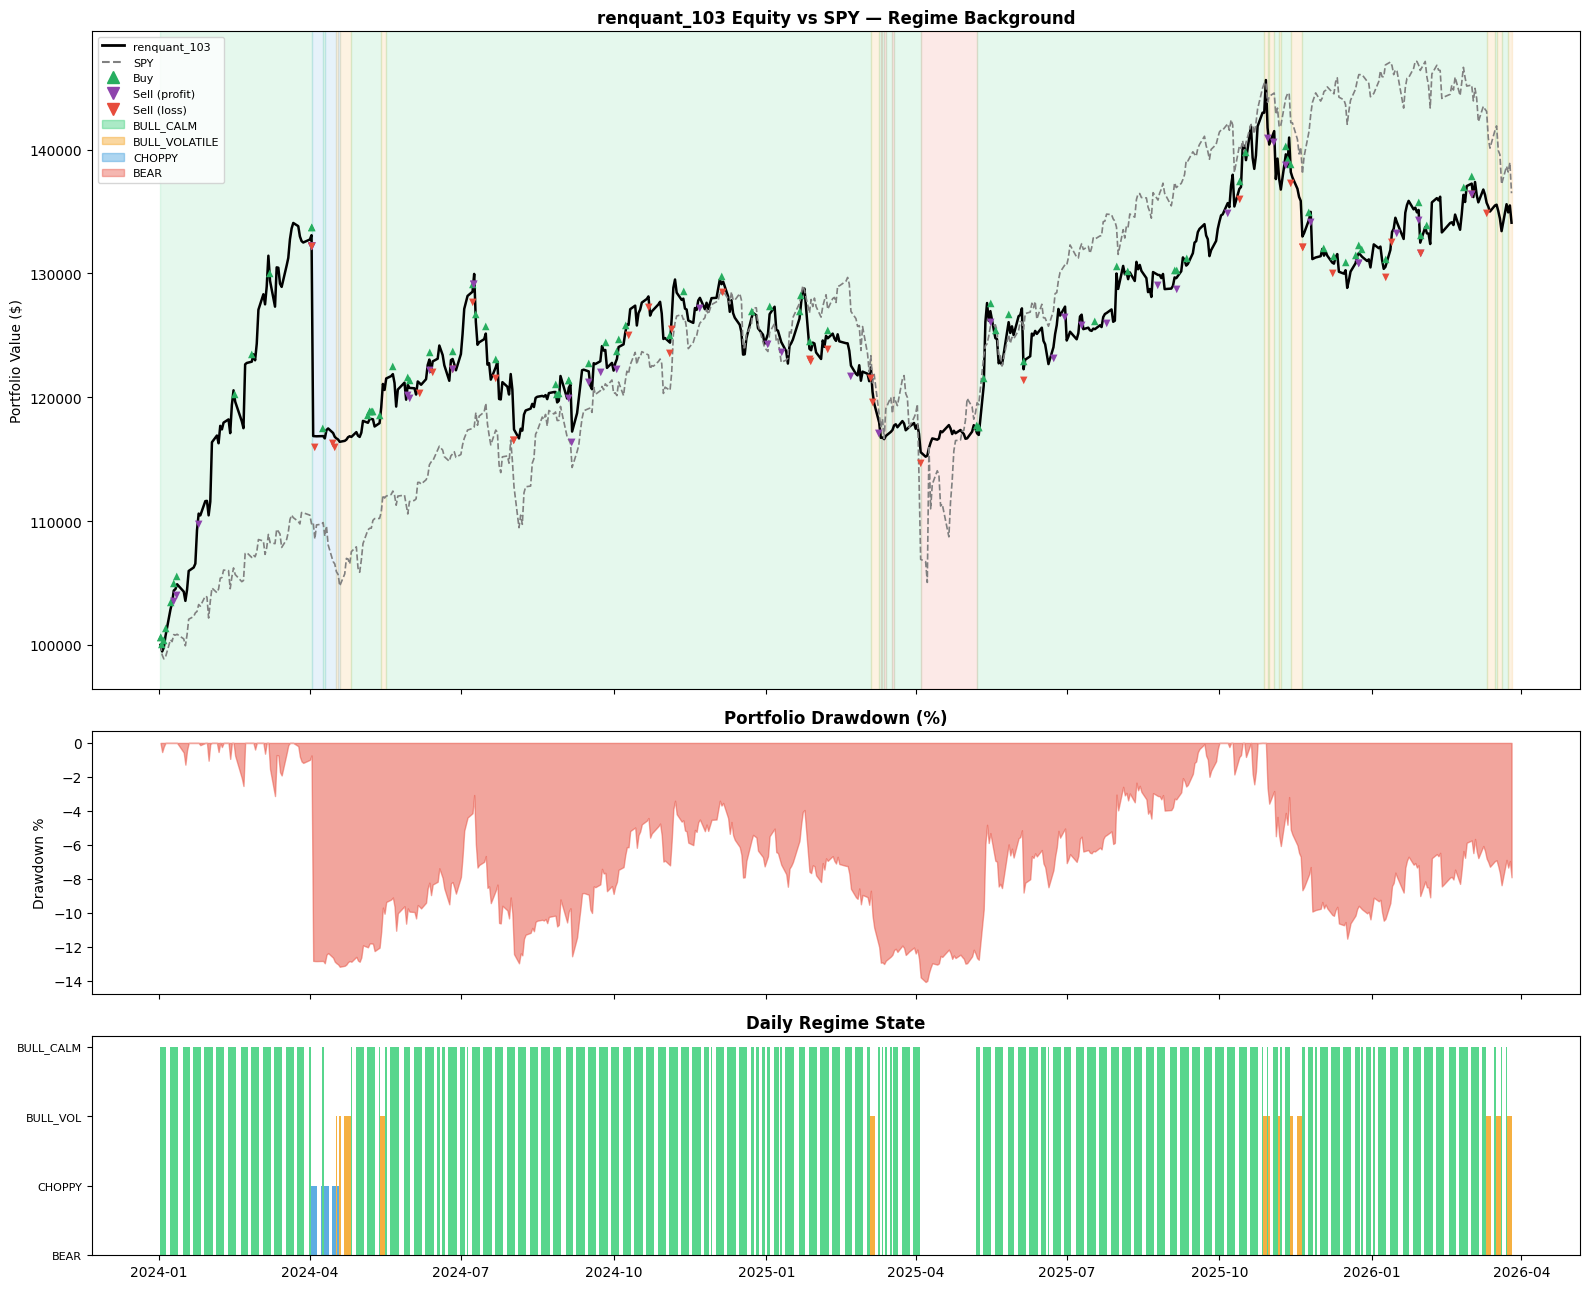

In [10]:
# SPY benchmark
spy_bt = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]
spy_norm = spy_bt / spy_bt.iloc[0] * INITIAL_CASH

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.2, 1]})

# ── Panel 1: Equity curve with regime background ──
ax = axes[0]
port_norm = equity_df["portfolio"]

# Shade by regime
prev_r = None; start_d = None
for d in equity_df.index:
    r = equity_df.loc[d, "regime"]
    if r != prev_r:
        if prev_r:
            ax.axvspan(start_d, d, alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))
        prev_r  = r; start_d = d
if prev_r:
    ax.axvspan(start_d, equity_df.index[-1], alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))

ax.plot(port_norm.index, port_norm.values, color="black", lw=1.8, label="renquant_103")
ax.plot(spy_norm.index,  spy_norm.values,  color="grey",  lw=1.2, ls="--", label="SPY")

# ── Buy/sell markers ──
buy_trades  = [t for t in trade_log if t["action"] == "buy"  and t["date"] in port_norm.index]
sell_trades = [t for t in trade_log if t["action"] == "sell" and t["date"] in port_norm.index]
for t in buy_trades:
    ax.annotate("▲", xy=(t["date"], port_norm.loc[t["date"]]),
                fontsize=7, color="#27ae60", ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points")
for t in sell_trades:
    pnl = t.get("pnl_pct", 0)
    color = "#e74c3c" if pnl < 0 else "#8e44ad"
    ax.annotate("▼", xy=(t["date"], port_norm.loc[t["date"]]),
                fontsize=7, color=color, ha="center", va="top",
                xytext=(0, -3), textcoords="offset points")

patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=[
    plt.Line2D([0],[0],color="black",lw=2,label="renquant_103"),
    plt.Line2D([0],[0],color="grey",lw=1.5,ls="--",label="SPY"),
    plt.Line2D([0],[0],marker="^",color="#27ae60",lw=0,markersize=8,label="Buy"),
    plt.Line2D([0],[0],marker="v",color="#8e44ad",lw=0,markersize=8,label="Sell (profit)"),
    plt.Line2D([0],[0],marker="v",color="#e74c3c",lw=0,markersize=8,label="Sell (loss)"),
] + patches, fontsize=8)
ax.set_title("renquant_103 Equity vs SPY — Regime Background", fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")

# ── Panel 2: Drawdown ──
ax = axes[1]
roll_max = port_norm.cummax()
drawdown = (port_norm - roll_max) / roll_max * 100
ax.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
ax.set_title("Portfolio Drawdown (%)", fontweight="bold")
ax.set_ylabel("Drawdown %")

# ── Panel 3: Regime state ──
ax = axes[2]
regime_numeric = {BULL_CALM: 3, BULL_VOLATILE: 2, CHOPPY: 1, BEAR: 0}
regime_vals    = equity_df["regime"].map(regime_numeric).fillna(-1)
colors_seq     = equity_df["regime"].map(REGIME_COLORS).fillna("grey")

ax.bar(regime_vals.index, regime_vals.values,
       color=colors_seq.values, width=1, alpha=0.8)
ax.set_yticks([0,1,2,3])
ax.set_yticklabels(["BEAR","CHOPPY","BULL_VOL","BULL_CALM"], fontsize=8)
ax.set_title("Daily Regime State", fontweight="bold")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "portfolio_simulation.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# ── Performance statistics ──

def calc_stats(series):
    """Compute standard performance metrics from an equity series."""
    series = series.dropna()
    daily_ret = series.pct_change().dropna()
    n_years = len(daily_ret) / 252
    total_return = series.iloc[-1] / series.iloc[0] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
    sharpe = float(daily_ret.mean() / daily_ret.std() * np.sqrt(252)) if daily_ret.std() > 0 else 0
    roll_max = series.cummax()
    max_dd = float(((series - roll_max) / roll_max).min())
    volatility = float(daily_ret.std() * np.sqrt(252))
    return {"total_return": total_return, "cagr": cagr, "sharpe": sharpe,
            "max_drawdown": max_dd, "volatility": volatility}

stats     = calc_stats(equity_df["portfolio"])
spy_stats = calc_stats(spy_norm)

print("=" * 45)
print(f"{'Metric':<25} {'103':>8}  {'SPY':>8}")
print("=" * 45)
# Add APY to stats dict (same formula as CAGR but labeled for clarity)
stats["apy"]     = stats["cagr"]
spy_stats["apy"] = spy_stats["cagr"]

for k in ["total_return", "apy", "sharpe", "max_drawdown", "volatility"]:
    v103 = stats.get(k, 0)
    vspy = spy_stats.get(k, 0)
    if k in ("total_return", "apy", "max_drawdown", "volatility"):
        print(f"{k:<25} {v103:>7.1%}  {vspy:>7.1%}")
    else:
        print(f"{k:<25} {v103:>8.3f}  {vspy:>8.3f}")
print("=" * 45)

# Regime breakdown
print("\nRegime days:")
for r, c in REGIME_COLORS.items():
    n = (equity_df["regime"] == r).sum()
    pct = n / len(equity_df)
    print(f"  {r:<16} {n:>4}d  {pct:.1%}")

Metric                         103       SPY
total_return                34.1%    36.5%
apy                         14.1%    15.1%
sharpe                       0.864     0.952
max_drawdown               -14.1%   -19.0%
volatility                  17.0%    16.1%

Regime days:
  BULL_CALM         493d  88.0%
  BULL_VOLATILE      30d  5.4%
  CHOPPY             11d  2.0%
  BEAR               26d  4.6%


## 10b  Trade Log & Detailed Analysis

In [12]:
# ── All trades table ──
import pandas as pd

if trade_log:
    tdf = pd.DataFrame(trade_log)
    tdf["date"] = pd.to_datetime(tdf["date"])

    # Buys
    buys_df = tdf[tdf["action"] == "buy"][["date","ticker","price","shares","invest"]].copy()
    buys_df = buys_df.rename(columns={"price":"entry_price","shares":"qty","invest":"invested"})
    buys_df["invested"] = buys_df["invested"].map("${:,.0f}".format)
    buys_df["entry_price"] = buys_df["entry_price"].map("${:.2f}".format)
    buys_df["qty"] = buys_df["qty"].map("{:.2f}".format)
    buys_df["date"] = buys_df["date"].dt.date

    # Sells
    sells_df = tdf[tdf["action"] == "sell"][["date","ticker","pnl_pct","hold_days","tax"]].copy()
    sells_df["pnl_pct"] = sells_df["pnl_pct"].map("{:+.1%}".format)
    sells_df["tax"] = sells_df["tax"].map("${:,.0f}".format)
    sells_df["date"] = sells_df["date"].dt.date
    sells_df = sells_df.rename(columns={"date":"sell_date","pnl_pct":"P&L","hold_days":"hold_d","tax":"tax_paid"})

    print(f"\n{'='*60}")
    print(f"  TRADE LOG — {len(buys_df)} buys, {len(sells_df)} sells")
    print(f"{'='*60}")
    print("\nBUYS:")
    print(buys_df.to_string(index=False))
    print("\nSELLS:")
    print(sells_df.to_string(index=False))
else:
    print("No trades recorded.")



  TRADE LOG — 80 buys, 76 sells

BUYS:
      date ticker entry_price    qty invested
2024-01-02   NVDA      $48.17 311.00  $14,980
2024-01-02    AMD     $138.58 108.00  $14,967
2024-01-03   META     $344.47  43.00  $14,812
2024-01-04    LLY     $614.50  23.00  $14,134
2024-01-05    GLD     $189.35  79.00  $14,959
2024-01-08    CAT     $292.25  52.00  $15,197
2024-01-10   NFLX      $47.83 322.00  $15,402
2024-01-12    JPM     $169.05  86.00  $14,538
2024-02-16    GLD     $186.34  95.00  $17,702
2024-02-26    LLY     $771.92  10.00   $7,719
2024-03-08    XLU      $31.88  11.00     $351
2024-04-02    AMD     $178.70   1.00     $179
2024-04-02   TSLA     $166.63   1.00     $167
2024-04-09   AAPL     $169.67  92.00  $15,610
2024-05-06    LLY     $766.68  21.00  $16,100
2024-05-07   PLTR      $21.40 762.00  $16,307
2024-05-07    AMD     $154.43 105.00  $16,215
2024-05-08    CAT     $344.50  45.00  $15,502
2024-05-09    GLD     $216.95  72.00  $15,620
2024-05-13    JPM     $198.73  69.00  $1

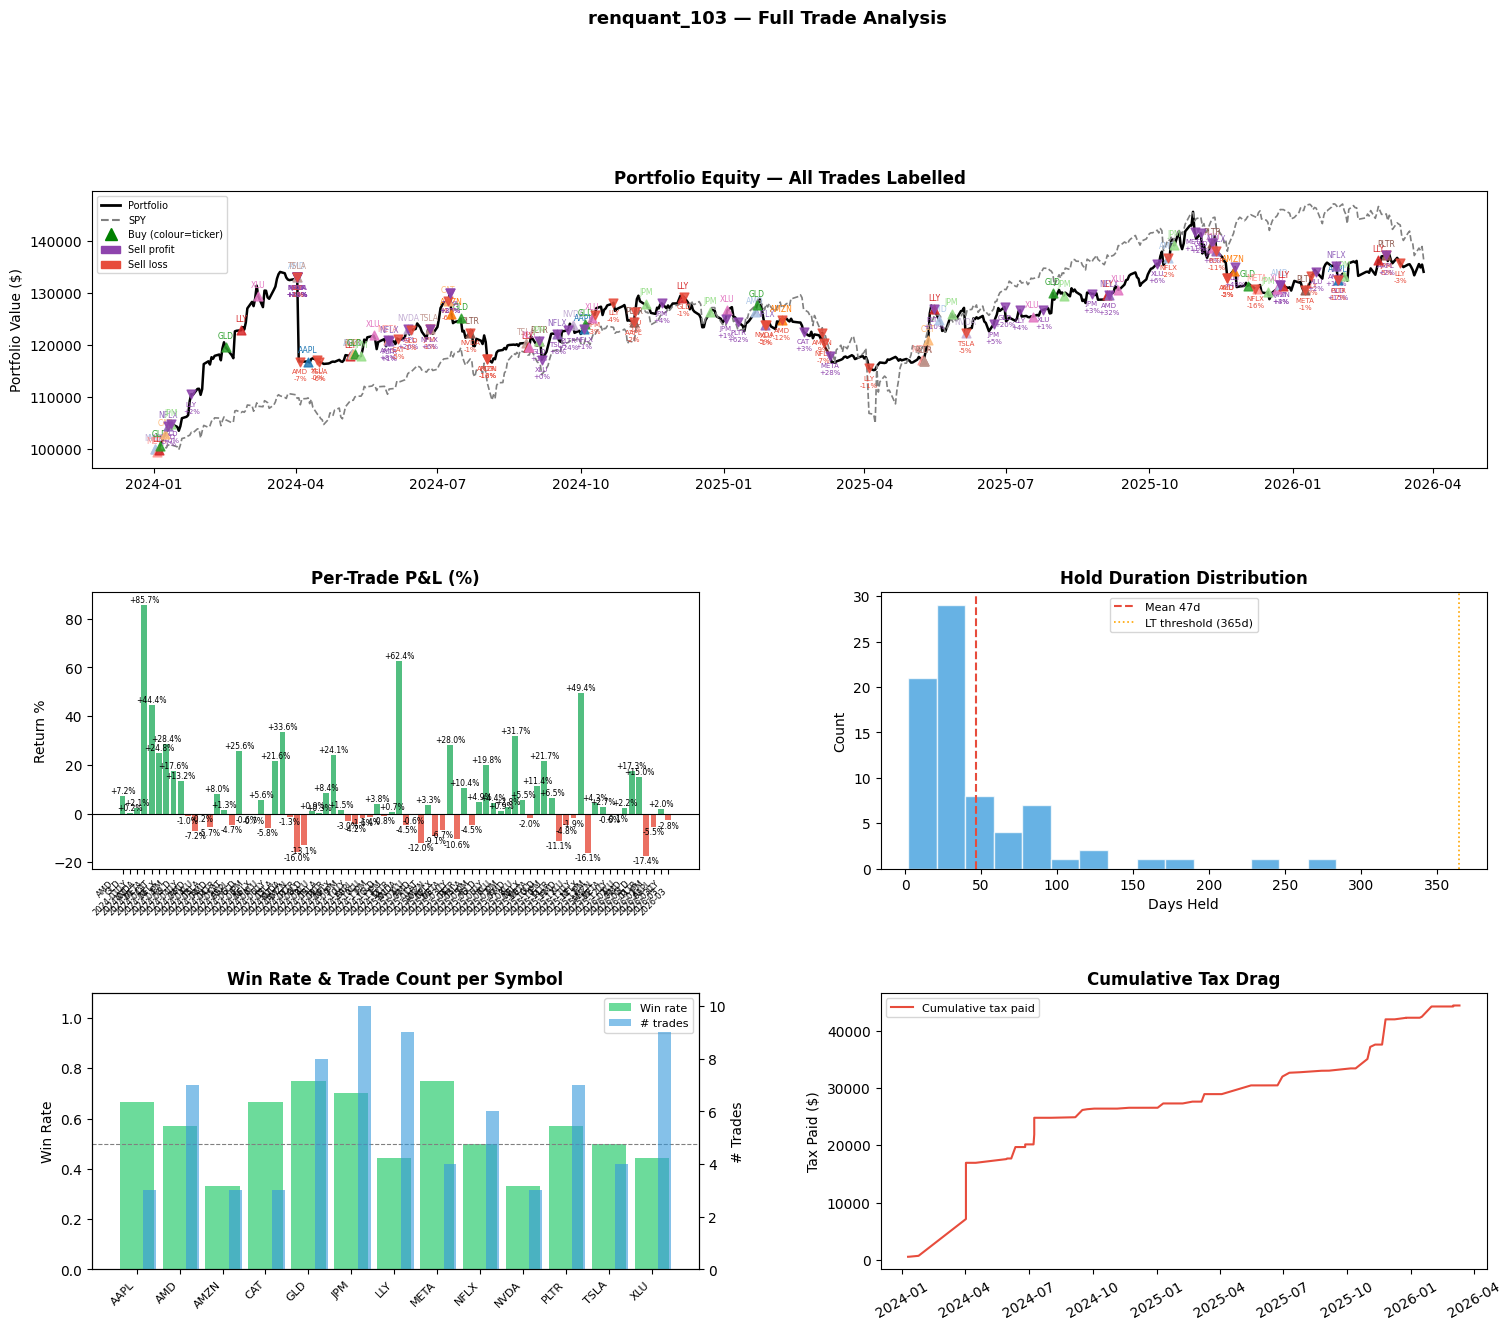

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/img/trade_analysis.png


In [13]:
# ── Detailed trade chart: per-symbol equity + P&L bars + hold durations ──
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

sells = [t for t in trade_log if t["action"] == "sell"]
buys  = [t for t in trade_log if t["action"] == "buy"]

if not sells and not buys:
    print("No trades to chart.")
else:
    tickers_traded = sorted(set([t["ticker"] for t in buys + sells]))
    colors_t = plt.cm.tab20.colors

    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # ── Panel (0,0): Portfolio equity with per-ticker labeled buy/sell markers ──
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(equity_df.index, equity_df["portfolio"], color="black", lw=1.8, label="Portfolio")
    ax0.plot(spy_norm.index, spy_norm.values, color="grey", lw=1.2, ls="--", label="SPY")

    ticker_colors = {t: colors_t[i % 20] for i, t in enumerate(tickers_traded)}
    for trade in buys:
        d = trade["date"]
        if d in equity_df.index:
            c = ticker_colors.get(trade["ticker"], "green")
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="^", color=c,
                        s=40, zorder=5, alpha=0.85)
            ax0.annotate(trade["ticker"], xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5.5, color=c, ha="center", va="bottom",
                         xytext=(0, 5), textcoords="offset points")
    for trade in sells:
        d = trade["date"]
        if d in equity_df.index:
            c = "#e74c3c" if trade["pnl_pct"] < 0 else "#8e44ad"
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="v", color=c,
                        s=40, zorder=5, alpha=0.85)
            ax0.annotate(f"{trade['ticker']}\n{trade['pnl_pct']:+.0%}",
                         xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5, color=c, ha="center", va="top",
                         xytext=(0, -5), textcoords="offset points")

    legend_handles = [
        plt.Line2D([0],[0],color="black",lw=2,label="Portfolio"),
        plt.Line2D([0],[0],color="grey",lw=1.5,ls="--",label="SPY"),
        plt.Line2D([0],[0],marker="^",color="green",lw=0,markersize=8,label="Buy (colour=ticker)"),
        mpatches.Patch(color="#8e44ad",label="Sell profit"),
        mpatches.Patch(color="#e74c3c",label="Sell loss"),
    ]
    ax0.legend(handles=legend_handles, fontsize=7, loc="upper left")
    ax0.set_title("Portfolio Equity — All Trades Labelled", fontweight="bold")
    ax0.set_ylabel("Portfolio Value ($)")

    # ── Panel (1,0): Per-trade P&L bar chart ──
    ax1 = fig.add_subplot(gs[1, 0])
    if sells:
        sells_sorted = sorted(sells, key=lambda x: x["date"])
        labels = [f"{t['ticker']}\n{str(t['date'])[:7]}" for t in sells_sorted]
        pnls   = [t["pnl_pct"] * 100 for t in sells_sorted]
        colors_bar = ["#e74c3c" if p < 0 else "#27ae60" for p in pnls]
        bars = ax1.bar(range(len(pnls)), pnls, color=colors_bar, alpha=0.8)
        ax1.set_xticks(range(len(pnls)))
        ax1.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
        ax1.axhline(0, color="black", lw=0.8)
        ax1.set_title("Per-Trade P&L (%)", fontweight="bold")
        ax1.set_ylabel("Return %")
        for bar, pnl in zip(bars, pnls):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if pnl >= 0 else -0.3),
                     f"{pnl:+.1f}%", ha="center", va="bottom" if pnl >= 0 else "top", fontsize=5.5)
    else:
        ax1.text(0.5, 0.5, "No completed trades", ha="center", va="center")

    # ── Panel (1,1): Hold duration histogram ──
    ax2 = fig.add_subplot(gs[1, 1])
    if sells:
        hold_days = [t["hold_days"] for t in sells]
        ax2.hist(hold_days, bins=15, color="#3498db", alpha=0.75, edgecolor="white")
        ax2.axvline(np.mean(hold_days), color="#e74c3c", lw=1.5, ls="--",
                    label=f"Mean {np.mean(hold_days):.0f}d")
        ax2.axvline(365, color="orange", lw=1.2, ls=":", label="LT threshold (365d)")
        ax2.legend(fontsize=8)
        ax2.set_title("Hold Duration Distribution", fontweight="bold")
        ax2.set_xlabel("Days Held")
        ax2.set_ylabel("Count")
    else:
        ax2.text(0.5, 0.5, "No completed trades", ha="center", va="center")

    # ── Panel (2,0): Per-symbol trade count & win rate ──
    ax3 = fig.add_subplot(gs[2, 0])
    if sells:
        sym_data = {}
        for t in sells:
            sym_data.setdefault(t["ticker"], {"wins":0,"total":0})
            sym_data[t["ticker"]]["total"] += 1
            if t["pnl_pct"] > 0:
                sym_data[t["ticker"]]["wins"] += 1
        syms = sorted(sym_data)
        win_rates = [sym_data[s]["wins"] / sym_data[s]["total"] for s in syms]
        counts    = [sym_data[s]["total"] for s in syms]
        x = range(len(syms))
        ax3.bar(x, win_rates, color="#2ecc71", alpha=0.7, label="Win rate")
        ax3_r = ax3.twinx()
        ax3_r.bar([i + 0.3 for i in x], counts, width=0.3, color="#3498db", alpha=0.6, label="# trades")
        ax3.set_xticks(x); ax3.set_xticklabels(syms, rotation=45, ha="right", fontsize=8)
        ax3.set_ylim(0, 1.1); ax3.axhline(0.5, color="grey", lw=0.8, ls="--")
        ax3.set_title("Win Rate & Trade Count per Symbol", fontweight="bold")
        ax3.set_ylabel("Win Rate")
        ax3_r.set_ylabel("# Trades")
        lines1, labels1 = ax3.get_legend_handles_labels()
        lines2, labels2 = ax3_r.get_legend_handles_labels()
        ax3.legend(lines1+lines2, labels1+labels2, fontsize=8)

    # ── Panel (2,1): Cumulative tax paid vs gross P&L ──
    ax4 = fig.add_subplot(gs[2, 1])
    if sells:
        sells_sorted = sorted(sells, key=lambda x: x["date"])
        dates        = [t["date"] for t in sells_sorted]
        cum_tax      = np.cumsum([t["tax"] for t in sells_sorted])
        cum_gross_pnl = np.cumsum([t["pnl_pct"] * INITIAL_CASH / max(1, len(sells_sorted))
                                   for t in sells_sorted])
        ax4.plot(dates, cum_tax, color="#e74c3c", lw=1.5, label="Cumulative tax paid")
        ax4.set_title("Cumulative Tax Drag", fontweight="bold")
        ax4.set_ylabel("Tax Paid ($)")
        ax4.legend(fontsize=8)
        ax4.tick_params(axis="x", rotation=30)

    plt.suptitle("renquant_103 — Full Trade Analysis", fontsize=13, fontweight="bold", y=1.01)
    plt.savefig(STRATEGY_DIR / "img" / "trade_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {STRATEGY_DIR / 'img' / 'trade_analysis.png'}")


## 10c  Trading Frequency & Holdings Over Time

  TRADING FREQUENCY
  Backtest span : 560 trading days (2.2 years)
  Total buys    : 80  (36.0/yr,  3.0/mo)
  Total sells   : 76  (34.2/yr,  2.9/mo)
  Avg days btw buys  : 7.0
  Avg hold duration  : 47 days  (2.2 months)
  Median hold        : 30 days
  Buys/month    : min=0, max=9, avg=3.0



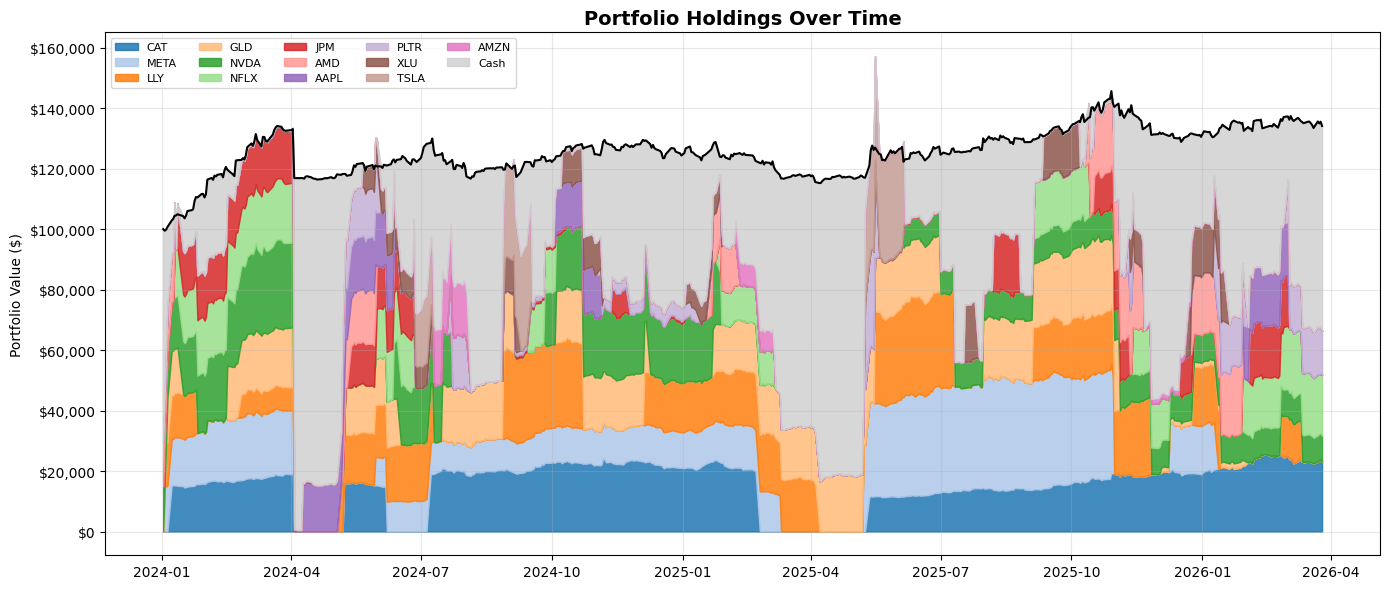

Saved → img/holdings_over_time.png


In [14]:
# ── Trading frequency summary ──────────────────────────────────────────────────
if trade_log:
    tdf_f = pd.DataFrame(trade_log)
    tdf_f["date"] = pd.to_datetime(tdf_f["date"])

    buys_td  = tdf_f[tdf_f["action"] == "buy"]
    sells_td = tdf_f[tdf_f["action"] == "sell"]
    total_days = len(equity_df)
    n_years   = total_days / 252

    print(f"{'='*55}")
    print(f"  TRADING FREQUENCY")
    print(f"{'='*55}")
    print(f"  Backtest span : {total_days} trading days ({n_years:.1f} years)")
    print(f"  Total buys    : {len(buys_td)}  ({len(buys_td)/n_years:.1f}/yr,  {len(buys_td)/(n_years*12):.1f}/mo)")
    print(f"  Total sells   : {len(sells_td)}  ({len(sells_td)/n_years:.1f}/yr,  {len(sells_td)/(n_years*12):.1f}/mo)")
    if len(buys_td) > 0:
        print(f"  Avg days btw buys  : {total_days/len(buys_td):.1f}")
    if len(sells_td) > 0:
        avg_hold = sells_td["hold_days"].mean()
        med_hold = sells_td["hold_days"].median()
        print(f"  Avg hold duration  : {avg_hold:.0f} days  ({avg_hold/21:.1f} months)")
        print(f"  Median hold        : {med_hold:.0f} days")
    monthly_buys = buys_td.set_index("date").resample("ME").size()
    print(f"  Buys/month    : min={monthly_buys.min()}, max={monthly_buys.max()}, avg={monthly_buys.mean():.1f}")
else:
    print("No trades recorded.")

print()

# ── Portfolio holdings over time (cash vs stock stacked area) ──────────────────
if trade_log:
    tdf_h = pd.DataFrame(trade_log)
    tdf_h["date"] = pd.to_datetime(tdf_h["date"])
    bt_idx = equity_df.index

    open_pos: dict = {}
    ticker_daily: dict = {}

    for _, row in tdf_h.sort_values("date").iterrows():
        t = row["ticker"]
        if row["action"] == "buy":
            open_pos.setdefault(t, []).append({"buy_date": row["date"], "shares": float(row["shares"])})
        elif row["action"] == "sell" and open_pos.get(t):
            pos = open_pos[t].pop(0)
            buy_d, shares = pos["buy_date"], pos["shares"]
            if t in ohlcv:
                prices = ohlcv[t]["close"].loc[buy_d:row["date"]]
                prices = prices[prices.index.isin(bt_idx)]
                ticker_daily.setdefault(t, pd.Series(0.0, index=bt_idx))
                ticker_daily[t] = ticker_daily[t].add(prices * shares, fill_value=0)

    for t, positions_list in open_pos.items():
        for pos in positions_list:
            buy_d, shares = pos["buy_date"], pos["shares"]
            if t in ohlcv:
                prices = ohlcv[t]["close"].loc[buy_d:]
                prices = prices[prices.index.isin(bt_idx)]
                ticker_daily.setdefault(t, pd.Series(0.0, index=bt_idx))
                ticker_daily[t] = ticker_daily[t].add(prices * shares, fill_value=0)

    if ticker_daily:
        hdf = pd.DataFrame(ticker_daily, index=bt_idx).fillna(0)
        hdf["Cash"] = (equity_df["portfolio"] - hdf.sum(axis=1)).clip(lower=0)
        stock_cols = sorted([c for c in hdf.columns if c != "Cash"],
                            key=lambda c: hdf[c].sum(), reverse=True)

        fig, ax = plt.subplots(figsize=(14, 6))
        colors = plt.cm.tab20.colors
        bottom = pd.Series(0.0, index=bt_idx)
        for i, col in enumerate(stock_cols + ["Cash"]):
            color = "#d0d0d0" if col == "Cash" else colors[i % len(colors)]
            ax.fill_between(hdf.index, bottom, bottom + hdf[col],
                            label=col, alpha=0.85, color=color)
            bottom = bottom + hdf[col]

        ax.plot(equity_df["portfolio"], color="black", lw=1.5, zorder=5)
        ax.set_title("Portfolio Holdings Over Time", fontsize=14, fontweight="bold")
        ax.set_ylabel("Portfolio Value ($)")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
        ax.legend(loc="upper left", fontsize=8, ncol=5)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(STRATEGY_DIR / "img" / "holdings_over_time.png", dpi=150)
        plt.show()
        print("Saved → img/holdings_over_time.png")
    else:
        print("No position data to plot.")
else:
    print("No trades recorded.")

## 11  Per-Symbol OOS Equity Curves

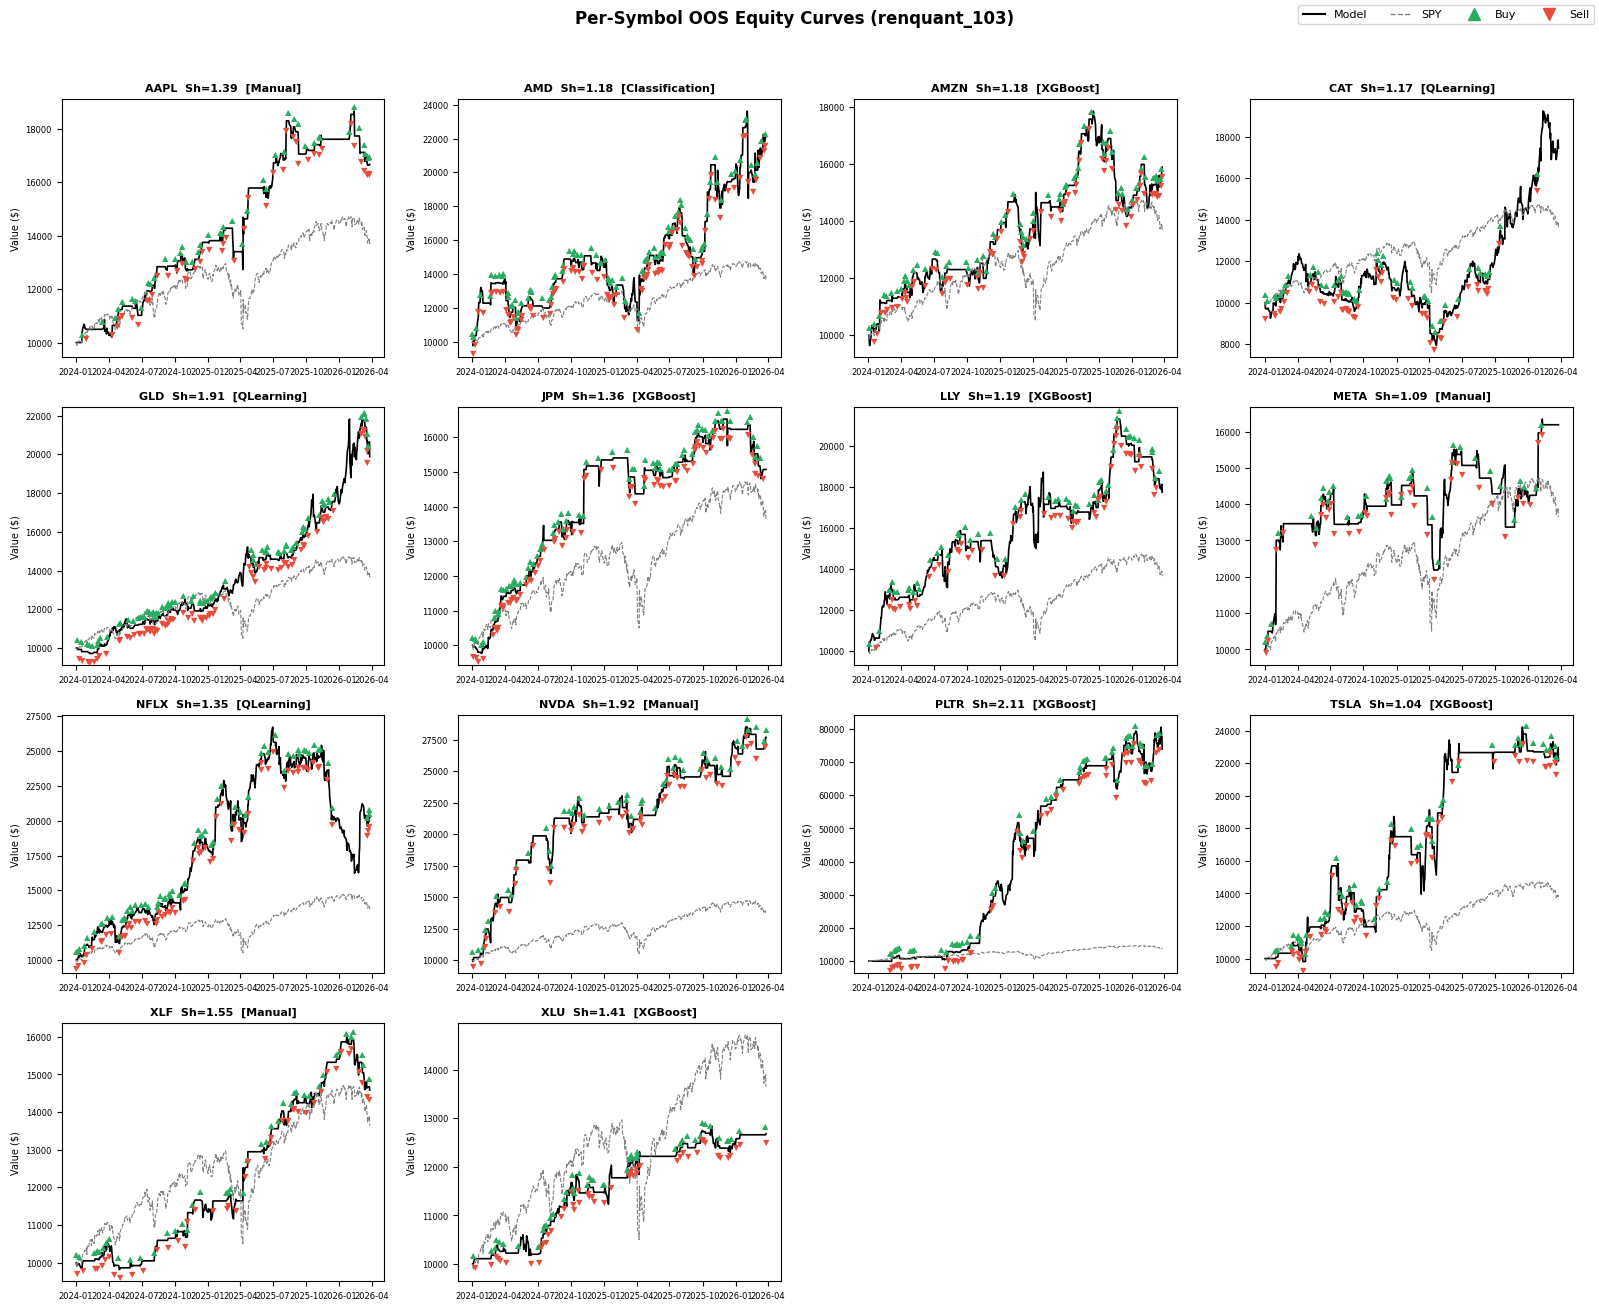

In [15]:
pass_tickers = sorted([t for t, r in results.items() if r.get("passes_floor")])

# Also include bootstrapped models that exist on disk
import json as _json
from pathlib import Path as _Path
model_dir = STRATEGY_DIR / "models"
for ticker in WATCHLIST:
    if ticker in pass_tickers:
        continue
    meta = model_dir / ticker / f"{ticker}-policy-metadata.json"
    if meta.exists():
        with meta.open() as _f:
            _m = _json.load(_f)
        if ticker not in results:
            results[ticker] = {
                "sharpe": _m.get("sharpe", 0),
                "best_approach": _m.get("best_approach", "bootstrapped"),
                "passes_floor": True,
                "oos_signals": None,
                "oos_prices": ohlcv.get(ticker, pd.DataFrame())["close"] if ticker in ohlcv else pd.Series(),
                "oos_rows": 0,
            }
            pass_tickers.append(ticker)

pass_tickers = sorted(set(pass_tickers))

if not pass_tickers:
    print("No models available — run Section 5 (training) first.")
else:
    ncols = 4
    nrows = max(1, (len(pass_tickers) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
    axes = np.array(axes).flatten()

    spy_oos_close = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]

    for i, ticker in enumerate(pass_tickers):
        ax     = axes[i]
        r      = results[ticker]
        sigs   = r["oos_signals"]
        prices = r["oos_prices"].loc[BACKTEST_START:BACKTEST_END]

        if sigs is None or prices.empty:
            ax.set_title(f"{ticker} — no OOS data", fontsize=8); continue

        sigs_bt = sigs.reindex(prices.index).fillna(0)
        try:
            pos       = sigs_bt.clip(0, 1).shift(1).fillna(0)
            strat_ret = prices.pct_change().fillna(0) * pos
            pv        = 10_000 * (1 + strat_ret).cumprod()
            spy_sub   = spy_oos_close.reindex(prices.index)
            spy_sub   = spy_sub / spy_sub.iloc[0] * 10_000

            ax.plot(pv.index,      pv.values,      color="black", lw=1.2, label="Model")
            ax.plot(spy_sub.index, spy_sub.values, color="grey",  lw=0.8, ls="--", label="SPY")

            # Buy/sell markers from signal transitions
            prev_sig = 0.0
            for dt in pv.index:
                cur_sig = float(sigs_bt.loc[dt]) if dt in sigs_bt.index else 0.0
                pv_val  = float(pv.loc[dt])
                if prev_sig != 1.0 and cur_sig == 1.0:   # entry
                    ax.annotate("▲", xy=(dt, pv_val), fontsize=6, color="#27ae60",
                                ha="center", va="bottom",
                                xytext=(0, 3), textcoords="offset points")
                elif prev_sig == 1.0 and cur_sig != 1.0:  # exit
                    ax.annotate("▼", xy=(dt, pv_val), fontsize=6, color="#e74c3c",
                                ha="center", va="top",
                                xytext=(0, -3), textcoords="offset points")
                prev_sig = cur_sig

            ax.set_title(f"{ticker}  Sh={r['sharpe']:.2f}  [{r['best_approach']}]",
                         fontsize=8, fontweight="bold")
            ax.set_ylabel("Value ($)", fontsize=7)
            ax.tick_params(labelsize=6)
        except Exception as e:
            ax.set_title(f"{ticker} — error: {e}", fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared legend
    fig.legend(handles=[
        plt.Line2D([0],[0], color="black", lw=1.5, label="Model"),
        plt.Line2D([0],[0], color="grey",  lw=1,   ls="--", label="SPY"),
        plt.Line2D([0],[0], marker="^", color="#27ae60", lw=0, markersize=8, label="Buy"),
        plt.Line2D([0],[0], marker="v", color="#e74c3c", lw=0, markersize=8, label="Sell"),
    ], loc="upper right", fontsize=8, ncol=4)

    plt.suptitle("Per-Symbol OOS Equity Curves (renquant_103)", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(STRATEGY_DIR / "img" / "per_symbol_oos.png", dpi=150, bbox_inches="tight")
    plt.show()


## 12  Fetch Earnings Calendar (run once)

In [16]:
# Run this cell to refresh the earnings calendar artifact.
# Can also run: python scripts/fetch_earnings_calendar.py --strategy renquant_103

import subprocess, sys
result = subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "fetch_earnings_calendar.py"),
     "--strategy", STRATEGY, "--lookahead", "90"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Fetching earnings calendar for 23 symbols → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/earnings-calendar.json
  TSLA... 1 dates
  AMZN... 1 dates
  GOOG... 1 dates
  MSFT... 1 dates
  AMD... 1 dates
  NFLX... 2 dates
  CRM... 1 dates
  PLTR... 1 dates
  UBER... 1 dates
  NVDA... 1 dates
  META... 1 dates
  AAPL... 1 dates
  JPM... 2 dates
  UNH... 1 dates
  CAT... 1 dates
  BA... 1 dates
  XLE... 0 dates
  XLF... 0 dates
  LLY... 1 dates
  GLD... 0 dates
  TLT... 0 dates
  XLV... 0 dates
  XLU... 0 dates

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_103/artifacts/earnings-calendar.json



## Done

Next steps:
1. Review regime charts (Section 3) — do the regime transitions make intuitive sense?
2. Check per-symbol Sharpe table (Section 8) — any symbols you want to add/remove?
3. Export LEAN data: `python scripts/export_lean_watchlist.py --strategy renquant_103`
4. Run LEAN backtest: `cd backtesting/renquant_103 && lean backtest .`
5. Analyse: `python scripts/analyze_backtest.py --strategy renquant_103`